# Notebook 04: Modèle sans le terme « transfer »

Ce notebook reprend fidèlement le pipeline du Notebook 03.  
La seule modification méthodologique est la suivante : le TF-IDF est ajusté sur une version du motif de consultation où le terme « transfer » et ses variantes ont été supprimés.

Toutes les variables structurées issues du Notebook 01 sont conservées et traitées comme dans le Notebook 03. Les splits, l'imputation, la standardisation, le MLP du Modèle 3, le critère de sélection clinique, le test interne, la validation temporelle et l'interprétabilité suivent la même chronologie.


## Plan

1. Configuration et imports  
2. Chargement de la cohorte produite par le Notebook 02  
2b. Analyse descriptive du terme « transfer » et du taux d'hospitalisation  
3. Définition des variables du modèle  
4. Création du texte NLP sans « transfer »  
5. Split patient-level et validation temporelle réservée  
6. Prétraitement tabulaire du modèle  
7. Prétraitement NLP — TF-IDF sans le terme « transfer »  
8. Construction des matrices finales  
9. Entraînement du MLP sur le Modèle 3  
10. Sélection du seuil clinique  
11. Évaluation sur test interne  
12. Validation temporelle  
13. Interprétabilité  
14. Vérification de l'absence de « transfer » dans le vocabulaire TF-IDF  
15. Sauvegarde finale


## 1. Configuration et imports


In [1]:
# Configuration et imports — cellule unique
import importlib
import subprocess
import sys
import json as _json
import math as _math
import warnings
from pathlib import Path

# Dépendances utilisées par ce notebook.
# Les installations sont faites seulement si le package est absent.
_DEPENDANCES = {
    'shap': 'shap',
    'seaborn': 'seaborn',
}

for module_name, pip_name in _DEPENDANCES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy import stats
from scipy.sparse import csr_matrix, hstack as sp_hstack, issparse
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, balanced_accuracy_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'target'

#  Chemins projet — bloc unifié, identique dans NB01 -> NB08
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"
for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
BLEU = '#2E5F8A'
ROUGE = '#C0392B'
VERT = '#27AE60'

print('Imports et configuration OK')


Imports et configuration OK


## 1b. Fonctions de sélection clinique


In [2]:
# Sélection clinique : priorité au recall, puis minimisation des fausses alertes
def safe_div(num, den):
    return num / den if den > 0 else 0


def seuil_pour_sensibilite(y_true, y_proba, se_cible=0.90):
    """Renvoie le plus haut seuil permettant d'obtenir Se >= se_cible.
    Ce choix maximise la spécificité sous contrainte de sensibilité.
    """
    fpr, tpr, thr = roc_curve(y_true, y_proba)
    ok = np.where(tpr >= se_cible)[0]
    if len(ok) == 0:
        return 0.0
    return float(thr[ok[0]])


def metriques_au_point(y_true, y_proba, seuil):
    """Métriques cliniques au seuil donné."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= seuil).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)

    se  = safe_div(tp, tp + fn)
    sp  = safe_div(tn, tn + fp)
    vpp = safe_div(tp, tp + fp)
    vpn = safe_div(tn, tn + fn)

    return {
        'Seuil': round(float(seuil), 3),
        'AUC': roc_auc_score(y_true, y_proba),
        'Se': se,
        'Sp': sp,
        'VPP': vpp,
        'VPN': vpn,
        'VP': int(tp),
        'VN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'Balanced_Accuracy': (se + sp) / 2,
        'Alertes/100': (tp + fp) / n * 100,
        'FP/100': fp / n * 100,
        'FN/100': fn / n * 100,
        'Brier': brier_score_loss(y_true, y_proba),
    }


def comparer_au_plancher_sensibilite(dict_proba, y_true, se_cible=0.90):
    """Compare les modèles à sensibilité fixée.
    Le meilleur modèle est celui qui donne la plus forte spécificité
    pour le même plancher de sensibilité.
    """
    rows = []
    for nom, proba in dict_proba.items():
        seuil = seuil_pour_sensibilite(y_true, proba, se_cible)
        m = metriques_au_point(y_true, proba, seuil)
        rows.append({'Algorithme': nom, **m})

    return (
        pd.DataFrame(rows)
        .sort_values(['Sp', 'AUC'], ascending=False)
        .reset_index(drop=True)
    )

# Test de DeLong : comparaison appariée des AUC
def _midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N)
    T2[J] = T
    return T2


def _fast_delong(preds_sorted, n_pos):
    """preds_sorted : (k_modeles, n_obs), positifs en premières colonnes."""
    m, k = n_pos, preds_sorted.shape[0]
    n = preds_sorted.shape[1] - m
    pos, neg = preds_sorted[:, :m], preds_sorted[:, m:]
    tx = np.array([_midrank(pos[r]) for r in range(k)])
    ty = np.array([_midrank(neg[r]) for r in range(k)])
    tz = np.array([_midrank(preds_sorted[r]) for r in range(k)])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(cov)


def delong_test(y_true, proba_a, proba_b):
    """Renvoie (auc_a, auc_b, p_value) pour H0 : AUC_a == AUC_b."""
    y_true = np.asarray(y_true)
    order = (-y_true).argsort(kind='mergesort')
    n_pos = int(y_true.sum())
    preds = np.vstack((np.asarray(proba_a)[order], np.asarray(proba_b)[order]))
    aucs, cov = _fast_delong(preds, n_pos)
    l = np.array([[1.0, -1.0]])
    var = float((l @ cov @ l.T)[0, 0])
    z = (aucs[0] - aucs[1]) / np.sqrt(var) if var > 0 else 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(aucs[0]), float(aucs[1]), float(p)


def matrice_delong(dict_proba, y_true):
    noms = list(dict_proba)
    M = pd.DataFrame(np.nan, index=noms, columns=noms)
    for i, a in enumerate(noms):
        for b in noms[i + 1:]:
            _, _, p = delong_test(y_true, dict_proba[a], dict_proba[b])
            M.loc[a, b] = M.loc[b, a] = round(p, 4)
    return M

# Calibration

def evaluer_calibration(dict_proba, y_true, n_bins=10):
    rows, courbes = [], {}
    for nom, proba in dict_proba.items():
        frac_pos, moy_pred = calibration_curve(
            y_true, proba, n_bins=n_bins, strategy='quantile'
        )
        courbes[nom] = (moy_pred, frac_pos)
        # ECE par déciles — même définition que dans le reste du pipeline
        # (NB03 calibration finale, NB07), pour que les valeurs soient comparables.
        _d = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(proba)})
        _d['bin'] = pd.qcut(_d['p'], n_bins, duplicates='drop')
        _g = _d.groupby('bin', observed=True).agg(n=('y', 'size'),
                                                 p_moy=('p', 'mean'),
                                                 obs=('y', 'mean'))
        _ece = float((_g['n'] * (_g['obs'] - _g['p_moy']).abs()).sum() / _g['n'].sum())
        rows.append({'Algorithme': nom,
                     'Brier': brier_score_loss(y_true, proba),
                     'ECE': _ece})
    return pd.DataFrame(rows).sort_values('Brier').reset_index(drop=True), courbes


def calibrer_modele(model_fit, X_calib, y_calib, methode='isotonic'):
    """Recalibre un modèle déjà entraîné sur un jeu de calibration dédié.
    À utiliser sur validation/calibration, jamais sur le test final.
    """
    calib = CalibratedClassifierCV(model_fit, method=methode, cv='prefit')
    calib.fit(X_calib, y_calib)
    return calib

print('Fonctions de sélection clinique OK ')


Fonctions de sélection clinique OK 


## 2. Chargement de la cohorte produite par le Notebook 02


In [3]:
input_path = OUT_DIR / 'cohort_nlp.csv'
if not input_path.exists():
    raise FileNotFoundError(
        f'Fichier introuvable : {input_path}\n'
        'Exécuter d\'abord le Notebook 02.'
    )

df = pd.read_csv(input_path, low_memory=False)
print(f'Cohorte chargée : {len(df):,} séjours × {df.shape[1]} colonnes')
print(f'Taux hospitalisation : {df[TARGET].mean()*100:.1f}%')

assert 'cleaned_complaint' in df.columns, 'cleaned_complaint absent — relancer NB02'
assert TARGET in df.columns, f'{TARGET} absent'


Cohorte chargée : 383,919 séjours × 38 colonnes
Taux hospitalisation : 38.2%


## 2b. Analyse descriptive du terme « transfer » et du taux d'hospitalisation

Cette section est placée juste après le chargement de la cohorte issue du Notebook 02. Elle compare le taux d'hospitalisation des séjours dont le motif contient une variante du terme `transfer` à celui des séjours dont le motif ne contient pas ce terme.  
Elle est purement descriptive et ne modifie pas la colonne NLP utilisée ensuite pour l'entraînement.

In [4]:
# Analyse descriptive — présence du terme transfer et taux d'hospitalisation
# On repère les variantes : transfer, transferred, transfers, transferring, etc.
pattern_transfer = r"\btransfer\w*\b"

if 'cleaned_complaint' not in df.columns:
    raise ValueError("Colonne 'cleaned_complaint' absente — relancer le Notebook 02.")
if TARGET not in df.columns:
    raise ValueError(f"Cible '{TARGET}' absente de la cohorte.")

mask_transfer = df['cleaned_complaint'].fillna('').str.contains(
    pattern_transfer,
    case=False,
    regex=True
)

n_total = len(df)
n_transfer = int(mask_transfer.sum())
n_no_transfer = int((~mask_transfer).sum())

prop_transfer = mask_transfer.mean() * 100 if n_total else np.nan
prop_no_transfer = (~mask_transfer).mean() * 100 if n_total else np.nan

hosp_transfer = df.loc[mask_transfer, TARGET].mean() * 100 if n_transfer > 0 else np.nan
hosp_no_transfer = df.loc[~mask_transfer, TARGET].mean() * 100 if n_no_transfer > 0 else np.nan

print(f"Séjours contenant 'transfer' : {n_transfer:,}")
print(f"Proportion de la cohorte : {mask_transfer.mean():.1%}")
print(f"Taux d'hospitalisation si 'transfer' présent : {hosp_transfer:.1f}%")
print(f"Taux d'hospitalisation si 'transfer' absent  : {hosp_no_transfer:.1f}%")

summary_transfer = pd.DataFrame({
    'Groupe': ['Transfer présent', 'Transfer absent'],
    'Effectif': [n_transfer, n_no_transfer],
    'Proportion_cohorte_%': [prop_transfer, prop_no_transfer],
    'Hospitalisés': [int(df.loc[mask_transfer, TARGET].sum()), int(df.loc[~mask_transfer, TARGET].sum())],
    'Taux_hospitalisation_%': [hosp_transfer, hosp_no_transfer]
})

display(summary_transfer)

# Sauvegarde du tableau descriptif.
RESULT_DIR.mkdir(parents=True, exist_ok=True)
out_table = RESULT_DIR / 'tab22_transfer_presence_hospit_sans.csv'
summary_transfer.to_csv(out_table, index=False)
print(f"Tableau sauvegardé : {out_table.resolve()}")

Séjours contenant 'transfer' : 20,432
Proportion de la cohorte : 5.3%
Taux d'hospitalisation si 'transfer' présent : 81.7%
Taux d'hospitalisation si 'transfer' absent  : 35.8%


,Groupe,Effectif,Proportion_cohorte_%,Hospitalisés,Taux_hospitalisation_%
0,Transfer présent,20432,5.321956,16692,81.695380
1,Transfer absent,363487,94.678044,130123,35.798529


Tableau sauvegardé : C:\Users\wdois\Desktop\Memoire_SDA7\results\tab22_transfer_presence_hospit_sans.csv


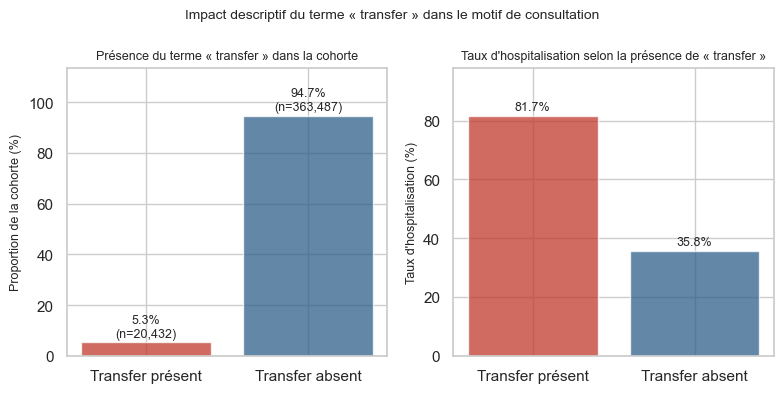

In [5]:
# Figure — présence du terme "transfer" et taux d'hospitalisation
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Couleurs cohérentes avec les notebooks précédents
color_present = ROUGE if 'ROUGE' in globals() else 'tab:red'
color_absent = BLEU if 'BLEU' in globals() else 'tab:blue'

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Graphique 1 — proportion dans la cohorte
axes[0].bar(
    summary_transfer['Groupe'],
    summary_transfer['Proportion_cohorte_%'],
    color=[color_present, color_absent],
    edgecolor='white',
    alpha=0.75
)

axes[0].set_title('Présence du terme « transfer » dans la cohorte', fontsize=9)
axes[0].set_ylabel('Proportion de la cohorte (%)', fontsize=9)
axes[0].set_ylim(0, max(summary_transfer['Proportion_cohorte_%']) * 1.2)

for i, v in enumerate(summary_transfer['Proportion_cohorte_%']):
    axes[0].text(
        i, v + 1,
        f"{v:.1f}%\n(n={summary_transfer.loc[i, 'Effectif']:,})",
        ha='center', va='bottom', fontsize=9
    )

# Graphique 2 — taux d'hospitalisation
axes[1].bar(
    summary_transfer['Groupe'],
    summary_transfer['Taux_hospitalisation_%'],
    color=[color_present, color_absent],
    edgecolor='white',
    alpha=0.75
)

axes[1].set_title("Taux d'hospitalisation selon la présence de « transfer »", fontsize=9)
axes[1].set_ylabel("Taux d'hospitalisation (%)", fontsize=9)
axes[1].set_ylim(0, max(summary_transfer['Taux_hospitalisation_%']) * 1.2)

for i, v in enumerate(summary_transfer['Taux_hospitalisation_%']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    'Impact descriptif du terme « transfer » dans le motif de consultation',
    fontsize=10
)

plt.tight_layout()

out_path = FIG_DIR / 'fig23_transfer_presence_hospit_sans.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

#print(f"Figure sauvegardée : {out_path.resolve()}")

## 3. Définition des variables du modèle


In [6]:
#  Compatibilité NB01/NB02 — conservation des variables exportées par NB01
# NB02 sauvegarde normalement cohort_nlp.csv sans retirer de colonnes.
# Cette cellule vérifie les variables attendues depuis NB01, conserve df complet,
# puis construit les variables numériques/encodées utilisables par les modèles.

NB01_EXPECTED_COLUMNS = [
    # Identifiants / temporalité / traçabilité — conservés mais non utilisés comme prédicteurs directs
    'subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start',
    'anchor_year', 'intime_year',
    # Cible / triage / constantes
    TARGET, 'acuity', 'heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature',
    # Âge / sexe
    'age_ed', 'anchor_age', 'gender',
    # Contexte et antécédents
    'pain', 'n_hosp_anterieures', 'arrival_transport', 'hour', 'day_of_week',
    # Texte NLP
    'cleaned_complaint',
    # Comorbidités
    'charlson_score_simplifie', 'charlson_score',
    'cm_dm_sans_complic', 'cm_dm_avec_complic',
    'cm_insuffisance_card', 'cm_bpco',
    'cm_insuffisance_renale', 'cm_cancer',
    'cm_cancer_meta', 'cm_infarctus',
    'cm_avc', 'cm_demence',
    'cm_maladie_foie', 'cm_vih_sida',
]

NB01_PRESENT_COLUMNS = [c for c in NB01_EXPECTED_COLUMNS if c in df.columns]
NB01_ABSENT_COLUMNS  = [c for c in NB01_EXPECTED_COLUMNS if c not in df.columns]

print(f'Variables NB01 retrouvées : {len(NB01_PRESENT_COLUMNS)} / {len(NB01_EXPECTED_COLUMNS)}')
if NB01_ABSENT_COLUMNS:
    print('Variables NB01 absentes ou non produites dans cette exécution :')
    print(NB01_ABSENT_COLUMNS)

# Garde-fou minimal pour les colonnes indispensables.
_REQUIRED_FOR_NB04 = ['subject_id', TARGET, 'cleaned_complaint']
_missing_required = [c for c in _REQUIRED_FOR_NB04 if c not in df.columns]
if _missing_required:
    raise ValueError(f'Colonnes indispensables absentes pour NB04 : {_missing_required}')

# Encodage déterministe des variables catégorielles exportées par NB01.
# Les colonnes brutes sont conservées dans df ; les colonnes *_ sont ajoutées pour les modèles.
NB01_CATEGORICAL_RAW = [c for c in ['gender', 'arrival_transport'] if c in df.columns]

def _normaliser_modalite(s):
    return (
        s.fillna('missing')
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '_', regex=True)
         .str.strip('_')
         .replace('', 'missing')
    )

def add_nb01_derived_features(df_input):
    """Ajoute les variables dérivées nécessaires au modèle sans supprimer les colonnes NB01."""
    df_out = df_input.copy()

    for col in NB01_CATEGORICAL_RAW:
        s = _normaliser_modalite(df_out[col])
        dummies = pd.get_dummies(s, prefix=col, dtype='int8')
        # On évite d'accumuler des dummies obsolètes si la cellule est réexécutée.
        old_dummy_cols = [c for c in df_out.columns if c.startswith(f'{col}_')]
        if old_dummy_cols:
            df_out = df_out.drop(columns=old_dummy_cols)
        df_out = pd.concat([df_out, dummies], axis=1)

    # Sécurisation numérique des variables explicitement numériques.
    for col in [
        'age_ed', 'anchor_age', 'acuity', 'heartrate', 'sbp', 'dbp', 'o2sat',
        'resprate', 'temperature', 'pain', 'n_hosp_anterieures', 'hour',
        'day_of_week', 'charlson_score_simplifie', 'charlson_score',
        'cm_dm_sans_complic', 'cm_dm_avec_complic', 'cm_insuffisance_card',
        'cm_bpco', 'cm_insuffisance_renale', 'cm_cancer', 'cm_cancer_meta',
        'cm_infarctus', 'cm_avc', 'cm_demence', 'cm_maladie_foie', 'cm_vih_sida'
    ]:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce')

    return df_out

# Enrichissement du DataFrame de travail, sans perte des variables NB01.
df = add_nb01_derived_features(df)

# Âge : age_ed en priorité si NB01 l'a produit ; sinon fallback anchor_age.
AGE_COL = 'age_ed' if 'age_ed' in df.columns else 'anchor_age'
if AGE_COL not in df.columns:
    raise ValueError('Aucune variable âge disponible : age_ed ou anchor_age doit être présente.')

# Comorbidité : charlson_score en priorité ; charlson_score_simplifie seulement en secours.
CHARLSON_COL = 'charlson_score' if 'charlson_score' in df.columns else 'charlson_score_simplifie'
CM_SCORE_COLS = [CHARLSON_COL] if CHARLSON_COL in df.columns else []

CM_FLAG_COLS = [c for c in [
    'cm_dm_sans_complic', 'cm_dm_avec_complic',
    'cm_insuffisance_card', 'cm_bpco',
    'cm_insuffisance_renale', 'cm_cancer',
    'cm_cancer_meta', 'cm_infarctus',
    'cm_avc', 'cm_demence',
    'cm_maladie_foie', 'cm_vih_sida',
] if c in df.columns]

VITAL_COLS = [c for c in ['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature'] if c in df.columns]
CONTEXT_COLS = [c for c in ['pain', 'n_hosp_anterieures', 'hour'] if c in df.columns]
TRIAGE_COLS = [c for c in ['acuity'] if c in df.columns]
CAT_ENCODED_COLS = [
    c for c in df.columns
    if c.startswith('gender_') or c.startswith('arrival_transport_')
]

# Colonnes de traçabilité conservées mais non utilisées comme variables explicatives directes.
TRACEABILITY_COLS = [
    c for c in ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start',
                'anchor_year', 'intime_year', TARGET, 'cleaned_complaint']
    if c in df.columns
]

#  Features par modèle
# M1 : constantes vitales + douleur + âge.
# M2 : M1 + toutes les variables structurées NB01 utilisables en prédiction
#      (ESI, contexte, antécédents, comorbidités, sexe et mode d'arrivée encodés).
# M3 : M2 + TF-IDF du motif de consultation.
features_m1 = list(dict.fromkeys(VITAL_COLS + [c for c in ['pain', AGE_COL] if c in df.columns]))
features_m2 = list(dict.fromkeys(
    features_m1 + TRIAGE_COLS +
    [c for c in CONTEXT_COLS if c not in features_m1] +
    CM_SCORE_COLS + CM_FLAG_COLS + CAT_ENCODED_COLS
))
features_m3 = features_m2  # + TF-IDF ajouté lors de l'assemblage
features_esi = ['acuity'] if 'acuity' in df.columns else []
all_num_features = list(dict.fromkeys(features_m3))

# Sécurisation : toutes les features de modèle doivent être numériques.
for col in all_num_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('\n=== Politique de variables NB04 ===')
print('Toutes les colonnes exportées par NB01 restent conservées dans df.')
print('Les identifiants, dates brutes, cible et texte sont gardés pour traçabilité/split, mais non utilisés comme prédicteurs structurés.')
print(f'M1 : {len(features_m1)} vars — constantes vitales + douleur + âge')
print(f'M2 : {len(features_m2)} vars — M1 + variables structurées NB01 utilisables')
print(f'M3 : {len(features_m3)} vars structurées + TF-IDF')
print(f'ESI seul : {features_esi}')
print(f'Variable âge utilisée : {AGE_COL}')
print(f'Variable comorbidité utilisée : {CM_SCORE_COLS}')
print(f'Flags comorbidité inclus : {len(CM_FLAG_COLS)}')
print(f'Catégorielles encodées : {CAT_ENCODED_COLS}')
print(f'Colonnes de traçabilité conservées : {TRACEABILITY_COLS}')
print('\nFeatures M2/M3 :')
print(features_m3)

Variables NB01 retrouvées : 38 / 38

=== Politique de variables NB04 ===
Toutes les colonnes exportées par NB01 restent conservées dans df.
Les identifiants, dates brutes, cible et texte sont gardés pour traçabilité/split, mais non utilisés comme prédicteurs structurés.
M1 : 8 vars — constantes vitales + douleur + âge
M2 : 31 vars — M1 + variables structurées NB01 utilisables
M3 : 31 vars structurées + TF-IDF
ESI seul : ['acuity']
Variable âge utilisée : age_ed
Variable comorbidité utilisée : ['charlson_score']
Flags comorbidité inclus : 12
Catégorielles encodées : ['gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Colonnes de traçabilité conservées : ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start', 'anchor_year', 'intime_year', 'target', 'cleaned_complaint']

Features M2/M3 :
['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'pain

## 4. Création du texte NLP sans `transfer`

À partir de ce point, le notebook reproduit le pipeline du Notebook 03.  
La seule modification est que le TF-IDF utilisera `complaint_sans_transfer` au lieu de `cleaned_complaint`.

Les patients ne sont pas supprimés et la cohorte n'est pas modifiée dans sa composition : seul le terme `transfer` et ses variantes sont retirés du texte NLP.


In [7]:
# Création du texte NLP sans le terme transfer.
# On retire les variantes commençant par transfer : transfer, transfers, transferred, transferring, etc.
# Cette colonne sert uniquement au TF-IDF du Notebook 04.

TEXT_COL_NLP = 'complaint_sans_transfer'
PATTERN_TRANSFER = r'\btransfer\w*\b'

if 'cleaned_complaint' not in df.columns:
    raise ValueError("Colonne 'cleaned_complaint' absente — relancer le Notebook 02.")

df[TEXT_COL_NLP] = (
    df['cleaned_complaint']
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(PATTERN_TRANSFER, ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

mask_transfer_original = df['cleaned_complaint'].fillna('').str.contains(
    PATTERN_TRANSFER, case=False, regex=True
)
mask_transfer_apres = df[TEXT_COL_NLP].fillna('').str.contains(
    PATTERN_TRANSFER, case=False, regex=True
)

print(f"Séjours dont le motif initial contient une variante de 'transfer' : {mask_transfer_original.sum():,} ({mask_transfer_original.mean()*100:.1f}%)")
print(f"Séjours dont le texte NLP sans transfer contient encore 'transfer' : {mask_transfer_apres.sum():,}")

assert mask_transfer_apres.sum() == 0, "Le terme transfer est encore présent dans complaint_sans_transfer."

cols_exemple = ['cleaned_complaint', TEXT_COL_NLP, TARGET]
cols_exemple = [c for c in cols_exemple if c in df.columns]
display(df.loc[mask_transfer_original, cols_exemple].head(10))


Séjours dont le motif initial contient une variante de 'transfer' : 20,432 (5.3%)
Séjours dont le texte NLP sans transfer contient encore 'transfer' : 0


,cleaned_complaint,complaint_sans_transfer,target
58,abdominal pain transfer,abdominal pain,1
108,headache transfer,headache,1
116,lethargy transfer,lethargy,1
136,alter mental status fall transfer,alter mental status fall,0
192,bradycardia transfer,bradycardia,1
200,fall transfer,fall,1
212,dysuria fever urinary tract infection transfer,dysuria fever urinary tract infection,0
228,abdominal pain melena transfer,abdominal pain melena,1
231,transfer hip fracture,hip fracture,1
237,abscess transfer,abscess,0


## 5. Split patient-level et validation temporelle réservée


In [8]:
#  Séparation patient-level stricte 
# La période 2017-2019 est réservée pour la validation temporelle.
# Dans le pool antérieur, on crée 3 jeux disjoints par patient :
#   - train : entraînement des modèles
#   - validation : sélection du modèle et du seuil clinique
#   - test : évaluation finale une seule fois
VALID_PERIOD = '2017 - 2019'
VALID_YEAR   = int(VALID_PERIOD.split(' - ')[0].strip())  # 2017

if 'ayg_start' not in df.columns:
    df['ayg_start'] = df['anchor_year_group'].str.extract(r'(\d{4})').astype(int)

df_train_pool = df[df['ayg_start'] < VALID_YEAR].copy()
df_valid_temp = df[df['ayg_start'] >= VALID_YEAR].copy()  # réservé validation temporelle

print(f'Pool développement : {len(df_train_pool):,} séjours (avant {VALID_PERIOD})')
print(f'Validation temporelle réservée : {len(df_valid_temp):,} séjours ({VALID_PERIOD})')

assert 'subject_id' in df.columns, 'subject_id absent'

# 1) On isole d'abord le test final interne.
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
dev_idx, test_idx = next(gss_test.split(df_train_pool, groups=df_train_pool['subject_id']))

df_dev  = df_train_pool.iloc[dev_idx].copy()
df_test = df_train_pool.iloc[test_idx].copy()

# 2) Dans le développement restant, on isole une validation pour choisir modèle + seuil.
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE + 1)
train_idx, val_idx = next(gss_val.split(df_dev, groups=df_dev['subject_id']))

df_train = df_dev.iloc[train_idx].copy()
df_val   = df_dev.iloc[val_idx].copy()

# Contrôle anti-leakage patient.
ids_train = set(df_train['subject_id'])
ids_val   = set(df_val['subject_id'])
ids_test  = set(df_test['subject_id'])

assert len(ids_train & ids_val)  == 0, 'LEAKAGE : patients communs train/validation'
assert len(ids_train & ids_test) == 0, 'LEAKAGE : patients communs train/test'
assert len(ids_val & ids_test)   == 0, 'LEAKAGE : patients communs validation/test'

# Sauvegarde acuity avant toute transformation.
acuity_val  = df_val['acuity'].copy()  if 'acuity' in df_val.columns  else None
acuity_test = df_test['acuity'].copy() if 'acuity' in df_test.columns else None

print(f'Train      : {len(df_train):,} séjours | {df_train["subject_id"].nunique():,} patients | '
      f'hospit. : {df_train[TARGET].mean()*100:.1f}%')
print(f'Validation : {len(df_val):,} séjours | {df_val["subject_id"].nunique():,} patients | '
      f'hospit. : {df_val[TARGET].mean()*100:.1f}%')
print(f'Test final : {len(df_test):,} séjours | {df_test["subject_id"].nunique():,} patients | '
      f'hospit. : {df_test[TARGET].mean()*100:.1f}%')
print('Leakage patient : 0 patient en commun')


Pool développement : 315,956 séjours (avant 2017 - 2019)
Validation temporelle réservée : 67,963 séjours (2017 - 2019)
Train      : 203,376 séjours | 87,700 patients | hospit. : 38.0%
Validation : 50,067 séjours | 21,925 patients | hospit. : 38.4%
Test final : 62,513 séjours | 27,407 patients | hospit. : 38.1%
Leakage patient : 0 patient en commun


### 5.1 Vérification du chevauchement patient avec la validation temporelle


In [9]:
# Vérification complémentaire : chevauchement de patients entre développement et validation temporelle.
# Cette vérification ne bloque pas l'analyse, mais permet de qualifier correctement
# la validation temporelle dans le mémoire.
patients_dev_pool = set(df_train_pool['subject_id'])
patients_temp = set(df_valid_temp['subject_id'])
overlap_temp = patients_dev_pool & patients_temp

print(f"Patients communs pool développement / validation temporelle : {len(overlap_temp):,}")
if len(patients_temp) > 0:
    print(f"Proportion des patients temporels concernés : {len(overlap_temp) / len(patients_temp):.1%}")

if len(overlap_temp) > 0:
    print("Note : validation temporelle par période de séjour, non totalement indépendante par patient.")
else:
    print("Aucun patient commun entre le pool de développement et la validation temporelle.")


Patients communs pool développement / validation temporelle : 0
Proportion des patients temporels concernés : 0.0%
Aucun patient commun entre le pool de développement et la validation temporelle.


## 6. Prétraitement tabulaire du modèle


In [10]:
print('=== VALEURS MANQUANTES — AVANT IMPUTATION ===')
print(f'{"Variable":<45} {"Train":>10} {"Val":>10} {"Test":>10}')
print('─' * 83)

has_missing = False
for col in all_num_features:
    if col not in df_train.columns:
        continue
    pct_train = df_train[col].isna().mean() * 100
    pct_val   = df_val[col].isna().mean()   * 100
    pct_test  = df_test[col].isna().mean()  * 100
    if pct_train > 0 or pct_val > 0 or pct_test > 0:
        has_missing = True
        flag = 'À vérifier' if pct_train > 20 else ''
        print(f'{col:<45} {pct_train:>9.1f}%  {pct_val:>9.1f}%  {pct_test:>9.1f}% {flag}')

if not has_missing:
    print('Aucune valeur manquante détectée dans les variables structurées du modèle')

print()
print(f'Total manquants train : {df_train[all_num_features].isna().sum().sum():,}')
print(f'Total manquants val   : {df_val[all_num_features].isna().sum().sum():,}')
print(f'Total manquants test  : {df_test[all_num_features].isna().sum().sum():,}')
print(f'Variables structurées conservées pour M3 : {len(all_num_features)}')

=== VALEURS MANQUANTES — AVANT IMPUTATION ===
Variable                                           Train        Val       Test
───────────────────────────────────────────────────────────────────────────────────
heartrate                                           0.3%        0.3%        0.3% 
sbp                                                 0.7%        0.6%        0.6% 
dbp                                                 1.0%        0.9%        1.0% 
o2sat                                               1.2%        1.2%        1.3% 
resprate                                            1.2%        1.2%        1.2% 
temperature                                         2.0%        1.9%        2.0% 
pain                                                6.9%        6.6%        6.7% 
acuity                                              0.0%        0.0%        0.1% 

Total manquants train : 27,001
Total manquants val   : 6,352
Total manquants test  : 8,257
Variables structurées conservées pour M3 : 

In [11]:
# La médiane est ajustée uniquement sur le train,
# puis appliquée à la validation et au test → aucun leakage d'information.
# Les colonnes catégorielles encodées sont déjà numériques ; elles restent incluses.
imputer = SimpleImputer(strategy='median')
feats_existing = [f for f in all_num_features if f in df_train.columns]

if not feats_existing:
    raise ValueError('Aucune variable structurée disponible pour l\'imputation.')

for _df_name, _df_obj in [('train', df_train), ('validation', df_val), ('test', df_test)]:
    _df_obj.loc[:, feats_existing] = _df_obj[feats_existing].apply(pd.to_numeric, errors='coerce')

df_train.loc[:, feats_existing] = imputer.fit_transform(df_train[feats_existing])
df_val.loc[:, feats_existing]   = imputer.transform(df_val[feats_existing])
df_test.loc[:, feats_existing]  = imputer.transform(df_test[feats_existing])

print(f'Imputation médiane: {len(feats_existing)} variables structurées')
print(f'Manquants restants train : {df_train[feats_existing].isna().sum().sum()}')
print(f'Manquants restants val   : {df_val[feats_existing].isna().sum().sum()}')
print(f'Manquants restants test  : {df_test[feats_existing].isna().sum().sum()}')

print('\n=== Médianes ajustées sur le train ===')
for col, med in zip(feats_existing, imputer.statistics_):
    print(f'  {col:<45} médiane={med:.2f}')

Imputation médiane: 31 variables structurées
Manquants restants train : 0
Manquants restants val   : 0
Manquants restants test  : 0

=== Médianes ajustées sur le train ===
  heartrate                                     médiane=83.00
  sbp                                           médiane=133.00
  dbp                                           médiane=77.00
  o2sat                                         médiane=99.00
  resprate                                      médiane=18.00
  temperature                                   médiane=36.67
  pain                                          médiane=5.00
  age_ed                                        médiane=55.00
  acuity                                        médiane=3.00
  n_hosp_anterieures                            médiane=1.00
  hour                                          médiane=14.00
  charlson_score                                médiane=0.00
  cm_dm_sans_complic                            médiane=0.00
  cm_dm_avec_complic      

## 7. Prétraitement NLP TF-IDF sans le terme « transfer »


In [12]:
# Le TF-IDF est ajusté uniquement sur le train, comme dans NB03.
# Seule différence : le texte source est complaint_sans_transfer.
y_train = df_train[TARGET]
y_val   = df_val[TARGET]
y_test  = df_test[TARGET]

tfidf = TfidfVectorizer(max_features=1000, min_df=5, ngram_range=(1, 2), dtype=np.float32)
X_train_tfidf = tfidf.fit_transform(df_train[TEXT_COL_NLP].fillna(''))
X_val_tfidf   = tfidf.transform(df_val[TEXT_COL_NLP].fillna(''))
X_test_tfidf  = tfidf.transform(df_test[TEXT_COL_NLP].fillna(''))

print(f'TF-IDF ajusté - vocabulaire : {len(tfidf.get_feature_names_out())} termes')

# Vérification de sécurité : aucun terme contenant 'transfer' ne doit rester dans le vocabulaire.
vocab_transfer = [t for t in tfidf.get_feature_names_out() if 'transfer' in t.lower()]
print(f"Termes contenant 'transfer' dans le vocabulaire : {vocab_transfer}")
assert len(vocab_transfer) == 0, "Le terme transfer est encore présent dans le vocabulaire TF-IDF."
print('Le vectorizer sera sauvegardé dans la section finale.')


TF-IDF ajusté - vocabulaire : 1000 termes
Termes contenant 'transfer' dans le vocabulaire : []
Le vectorizer sera sauvegardé dans la section finale.


## 8. Entraînement du MLP sur le Modèle 3


In [13]:
# Algorithme utilisé 
# Correction méthodologique : on entraîne uniquement le MLP sur le Modèle 3.
ALGORITHMES = {
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        batch_size=512,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ),
}


def get_metrics(y_true, y_proba, seuil=0.5):
    y_pred = (y_proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    se = safe_div(tp, tp + fn)
    sp = safe_div(tn, tn + fp)
    return {
        'AUC':              round(roc_auc_score(y_true, y_proba), 4),
        'Se':               round(se, 4),
        'Sp':               round(sp, 4),
        'VPP':              round(safe_div(tp, tp + fp), 4),
        'VPN':              round(safe_div(tn, tn + fn), 4),
        'VP': int(tp), 'VN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Balanced_Accuracy': round((se + sp) / 2, 4)
    }

print('Algorithme MLP et métriques définis')


Algorithme MLP et métriques définis


### 8.1 Comparateur clinique ESI seul, sans entraînement


In [14]:
# Initialisation des objets utilisés dans le notebook.
results, trained_models, probas, probas_test = [], {}, {}, {}

# Comparateur clinique ESI sans entraînement : utilisé uniquement comme repère descriptif.
# Le seul modèle entraîné dans ce notebook est le MLP sur le Modèle 3.
auc_esi, auc_esi_val = np.nan, np.nan
y_score_esi_val, y_score_esi_test = None, None

if 'acuity' in df_val.columns and 'acuity' in df_test.columns:
    print('=== Comparateur clinique : ESI seul, sans entraînement ===')

    y_score_esi_val = 6 - pd.to_numeric(df_val['acuity'], errors='coerce')
    y_score_esi_test = 6 - pd.to_numeric(df_test['acuity'], errors='coerce')

    mask_val = np.isfinite(y_val) & np.isfinite(y_score_esi_val)
    mask_test = np.isfinite(y_test) & np.isfinite(y_score_esi_test)

    if mask_val.sum() > 0 and len(np.unique(y_val[mask_val])) == 2:
        auc_esi_val = roc_auc_score(y_val[mask_val], y_score_esi_val[mask_val])
    if mask_test.sum() > 0 and len(np.unique(y_test[mask_test])) == 2:
        auc_esi = roc_auc_score(y_test[mask_test], y_score_esi_test[mask_test])

    print(f'AUC ESI validation : {auc_esi_val:.4f}' if np.isfinite(auc_esi_val) else 'AUC ESI validation : non calculable')
    print(f'AUC ESI test       : {auc_esi:.4f}' if np.isfinite(auc_esi) else 'AUC ESI test       : non calculable')
else:
    print('Comparateur ESI non calculé : variable acuity absente.')


=== Comparateur clinique : ESI seul, sans entraînement ===
AUC ESI validation : 0.6930
AUC ESI test       : 0.6922


### 8.2 Définition du Modèle 3


In [15]:
model_configs = [
    {'nom': 'Modèle 3: Variables structurées + NLP',
     'features': features_m3, 'use_nlp': True},
]
print('Modèle 3 défini')
print(f'M3 : {len(features_m3)} variables structurées  + 1000 TF-IDF')


Modèle 3 défini
M3 : 31 variables structurées  + 1000 TF-IDF


### 8.3 Entraînement du MLP sur le Modèle 3


In [16]:
print('*** Entraînement du MLP sur le Modèle 3 ***')

algo_name = 'MLP'
algo_template = ALGORITHMES[algo_name]
config = model_configs[0]
model_nom = config['nom']
feats_ok = [f for f in config['features'] if f in df_train.columns]

if not feats_ok:
    raise ValueError('Aucune variable structurée disponible pour le Modèle 3.')

# Prétraitement des variables structurées
# Le StandardScaler.fit_transform peut créer plusieurs copies temporaires en float64.
# Ici, on :
#   1. impute avec les médianes du train uniquement ;
#   2. convertit en float32 ;
#   3. calcule moyenne/écart-type sur le train ;
#   4. standardise en place.
# Cela garde exactement le principe anti-leakage : les paramètres sont appris sur le train.

train_fill_values_m3 = (
    df_train[feats_ok]
    .apply(pd.to_numeric, errors='coerce')
    .median(numeric_only=True)
    .reindex(feats_ok)
    .fillna(0.0)
    .astype('float32')
)

def _matrix_float32(df_input, cols, fill_values):
    """Convertit un DataFrame en matrice numérique float32 avec colonnes alignées."""
    X_df = df_input.reindex(columns=cols, fill_value=0)
    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X_df = X_df.fillna(fill_values)
    return X_df.to_numpy(dtype=np.float32, copy=True)

def _fit_scaler_float32(X_train):
    """Crée un objet compatible StandardScaler sans fit_transform coûteux."""
    scaler = StandardScaler(copy=False)
    mean = X_train.mean(axis=0, dtype=np.float64).astype(np.float32)
    scale = X_train.std(axis=0, dtype=np.float64).astype(np.float32)
    scale[~np.isfinite(scale) | (scale == 0)] = 1.0

    scaler.mean_ = mean
    scaler.scale_ = scale
    scaler.var_ = (scale.astype(np.float64) ** 2)
    scaler.n_features_in_ = X_train.shape[1]
    scaler.feature_names_in_ = np.array(feats_ok, dtype=object)
    scaler.n_samples_seen_ = X_train.shape[0]
    scaler.copy = False
    return scaler

def _transform_float32(X, scaler):
    """Standardisation en place, en float32."""
    X -= scaler.mean_.astype(np.float32)
    X /= scaler.scale_.astype(np.float32)
    return X

X_train_num = _matrix_float32(df_train, feats_ok, train_fill_values_m3)
X_val_num   = _matrix_float32(df_val,   feats_ok, train_fill_values_m3)
X_test_num  = _matrix_float32(df_test,  feats_ok, train_fill_values_m3)

scaler_local = _fit_scaler_float32(X_train_num)
X_train_scaled = _transform_float32(X_train_num, scaler_local)
X_val_scaled   = _transform_float32(X_val_num,   scaler_local)
X_test_scaled  = _transform_float32(X_test_num,  scaler_local)

# Modèle 3 : assemblage sparse TF-IDF + variables structurées
X_train_m3 = sp_hstack([csr_matrix(X_train_scaled, dtype=np.float32), X_train_tfidf.astype(np.float32)]).tocsr()
X_val_m3   = sp_hstack([csr_matrix(X_val_scaled,   dtype=np.float32), X_val_tfidf.astype(np.float32)]).tocsr()
X_test_m3  = sp_hstack([csr_matrix(X_test_scaled,  dtype=np.float32), X_test_tfidf.astype(np.float32)]).tocsr()
feats_m3, scaler_m3 = feats_ok, scaler_local

model_tmp = clone(algo_template).fit(X_train_m3, y_train)
y_proba_val_tmp  = model_tmp.predict_proba(X_val_m3)[:, 1]
y_proba_test_tmp = model_tmp.predict_proba(X_test_m3)[:, 1]

row = {'Algorithme': algo_name, 'Modèle': model_nom} | get_metrics(y_val, y_proba_val_tmp)
results.append(row)
trained_models[f'{algo_name} | {model_nom}'] = model_tmp
probas[f'{algo_name} | {model_nom}'] = y_proba_val_tmp
probas_test[f'{algo_name} | {model_nom}'] = y_proba_test_tmp

results_df = pd.DataFrame(results)
print(f'{model_nom:<45} AUC val={row["AUC"]:.4f}  Se val={row["Se"]:.4f}  FN val={row["FN"]:,}')
print(f'Matrice M3 train : {X_train_m3.shape} | dtype={X_train_m3.dtype}')
print('\nEntraînement terminé')

*** Entraînement du MLP sur le Modèle 3 ***
Modèle 3: Variables structurées + NLP         AUC val=0.8602  Se val=0.6631  FN val=6,473
Matrice M3 train : (203376, 1031) | dtype=float32

Entraînement terminé


### 8.4 Résultats sur validation interne


In [17]:
cols_base = [
    'Modèle', 'Algorithme', 'AUC', 'Se', 'Sp', 'VPP', 'VPN',
    'VP', 'VN', 'FP', 'FN', 'Balanced_Accuracy'
]
print('*** RÉSULTATS - VALIDATION INTERNE ***')
display(
    results_df[cols_base]
    .style
    .hide(axis="index")
    .format({
        "AUC": "{:.4f}",
        "Se": "{:.4f}",
        "Sp": "{:.4f}",
        "VPP": "{:.4f}",
        "VPN": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}",
        "VP": "{:,.0f}",
        "VN": "{:,.0f}",
        "FP": "{:,.0f}",
        "FN": "{:,.0f}",
    })
    .set_properties(
        subset=["Modèle", "Algorithme"],
        **{"text-align": "left"}
    )
    .set_properties(
        subset=["AUC", "Se", "Sp", "VPP", "VPN", "VP", "VN", "FP", "FN", "Balanced_Accuracy"],
        **{"text-align": "right"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [("text-align", "left")]
        }
    ])
)


*** RÉSULTATS - VALIDATION INTERNE ***


Modèle,Algorithme,AUC,Se,Sp,VPP,VPN,VP,VN,FP,FN,Balanced_Accuracy
Modèle 3: Variables structurées + NLP,MLP,0.8602,0.6631,0.8574,0.7433,0.8034,"12,742","26,451","4,401","6,473",0.7602


In [18]:
pivot_auc = (
    results_df
    .pivot_table(
        index="Modèle",
        columns="Algorithme",
        values="AUC",
        aggfunc="first"
    )
    .round(4)
)

display(
    pivot_auc
    .style
    .set_properties(**{
        "text-align": "left"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [("text-align", "left")]
        }
    ])
)

Algorithme,MLP
Modèle,
Modèle 3: Variables structurées + NLP,0.860200


Le MLP est entraîné uniquement sur le Modèle 3. Le seuil final est sélectionné sur la validation interne selon le critère clinique : sensibilité ≥ 90 %, puis meilleure spécificité.


## 9. Sélection clinique du seuil final


In [19]:
# Récupération du MLP entraîné sur le Modèle 3.
# Les métriques affichées ici sont calculées sur la validation interne.

key_mlp_m3 = 'MLP | Modèle 3: Variables structurées + NLP'
model_mlp_m3_base        = trained_models[key_mlp_m3]
y_proba_mlp_m3_base      = probas[key_mlp_m3].copy()
y_proba_mlp_m3_base_test = probas_test[key_mlp_m3].copy()
auc_mlp_m3_base          = roc_auc_score(y_val, y_proba_mlp_m3_base)
bacc_mlp_m3_base         = balanced_accuracy_score(y_val, (y_proba_mlp_m3_base >= 0.5).astype(int))

# Tableau informatif du Modèle 3.
df_m3_base = (
    results_df[results_df['Modèle'] == 'Modèle 3: Variables structurées + NLP']
    [['Algorithme', 'AUC', 'Balanced_Accuracy', 'Se', 'Sp', 'VPP', 'VPN', 'FN']]
    .sort_values(['AUC'], ascending=False)
    .reset_index(drop=True)
)
print('*** MLP - Modèle 3 - validation interne ***')
display(df_m3_base)
print(f'MLP | AUC validation={auc_mlp_m3_base:.4f} | Balanced Acc seuil 0.5={bacc_mlp_m3_base:.4f}')


*** MLP - Modèle 3 - validation interne ***


,Algorithme,AUC,Balanced_Accuracy,Se,Sp,VPP,VPN,FN
0,MLP,0.8602,0.7602,0.6631,0.8574,0.7433,0.8034,6473


MLP | AUC validation=0.8602 | Balanced Acc seuil 0.5=0.7602


In [20]:
# Sélection du seuil clinique pour le MLP sur le Modèle 3.
# La sélection ne se fait pas au seuil arbitraire 0,5.
# Principe : Se >= 90 %, puis meilleure Sp = moins de fausses alertes à recall fixé.

SE_CIBLE = 0.90

# Probabilités de validation et de test du MLP M3 déjà entraîné en section 8.
dict_proba_val = {
    'MLP': y_proba_mlp_m3_base,
}

dict_proba_test = {
    'MLP': y_proba_mlp_m3_base_test,
}

dict_models = {
    'MLP': model_mlp_m3_base,
}

# Tableau informatif au seuil 0,5, conservé uniquement pour lecture.
df_m3_base_05 = pd.DataFrame([
    {'Algorithme': nom} | get_metrics(y_val, proba, seuil=0.5)
    for nom, proba in dict_proba_val.items()
]).sort_values('AUC', ascending=False).reset_index(drop=True)

# Alias de compatibilité avec les cellules aval et d'anciens notebooks.
df_m3_opt_05 = df_m3_base_05.copy()

print('=' * 80)
print('TABLEAU INFORMATIF - MLP M3 - VALIDATION - SEUIL 0.5')
print('=' * 80)
display(df_m3_base_05[['Algorithme','AUC','Se','Sp','VPP','VPN','VP','VN','FP','FN','Balanced_Accuracy']])

# Critère clinique : sensibilité minimale puis spécificité maximale.
df_m3_selection = comparer_au_plancher_sensibilite(dict_proba_val, y_val, SE_CIBLE)

# Alias de compatibilité avec les cellules aval et d'anciens notebooks.
df_m3_opt = df_m3_selection.copy()

print('\n' + '=' * 80)
print(f'SÉLECTION CLINIQUE — MLP M3 — VALIDATION — Se >= {SE_CIBLE:.0%}, tri par spécificité')
print('=' * 80)
display(df_m3_selection[[
    'Algorithme','Seuil','AUC','Se','Sp','VPP','VPN',
    'VP','VN','FP','FN','Alertes/100','FP/100','FN/100','Brier','Balanced_Accuracy'
]])

best_row_opt  = df_m3_selection.iloc[0]
algo_opt      = best_row_opt['Algorithme']
model_m3_opt  = dict_models[algo_opt]

# Probabilités du modèle retenu : validation pour justification, test pour évaluation finale.
y_proba_m3_val = dict_proba_val[algo_opt]
y_proba_m3_opt = dict_proba_test[algo_opt]

# Seuil clinique figé sur la validation, puis appliqué au test dans la section 10.
seuil_90     = float(best_row_opt['Seuil'])
seuil_alerte = seuil_90
seuil_fort   = max(0.65, seuil_alerte + 0.05)

print('\n' + '=' * 80)
print('MODÈLE FINAL RETENU — AVANT TEST FINAL')
print('=' * 80)
print(f'Algorithme retenu        : {algo_opt}')
print(f'AUC validation           : {best_row_opt["AUC"]:.4f}')
print(f'Seuil clinique validation: {seuil_alerte:.3f}')
print(f'Sensibilité validation   : {best_row_opt["Se"]:.1%}')
print(f'Spécificité validation   : {best_row_opt["Sp"]:.1%}')
print(f'FP/100 validation        : {best_row_opt["FP/100"]:.1f}')
print(f'FN/100 validation        : {best_row_opt["FN/100"]:.1f}')


TABLEAU INFORMATIF - MLP M3 - VALIDATION - SEUIL 0.5


,Algorithme,AUC,Se,Sp,VPP,VPN,VP,VN,FP,FN,Balanced_Accuracy
0,MLP,0.8602,0.6631,0.8574,0.7433,0.8034,12742,26451,4401,6473,0.7602



SÉLECTION CLINIQUE — MLP M3 — VALIDATION — Se >= 90%, tri par spécificité


,Algorithme,Seuil,AUC,Se,Sp,VPP,VPN,VP,VN,FP,FN,Alertes/100,FP/100,FN/100,Brier,Balanced_Accuracy
0,MLP,0.217,0.860239,0.900026,0.603073,0.585443,0.906416,17294,18606,12246,1921,59.000939,24.459225,3.836859,0.147103,0.751549



MODÈLE FINAL RETENU — AVANT TEST FINAL
Algorithme retenu        : MLP
AUC validation           : 0.8602
Seuil clinique validation: 0.217
Sensibilité validation   : 90.0%
Spécificité validation   : 60.3%
FP/100 validation        : 24.5
FN/100 validation        : 3.8


### 9.1 Calibration sur validation interne


=== Calibration - Brier score sur validation - MLP M3 ===


,Algorithme,Brier,ECE
0,MLP,0.147103,0.012076


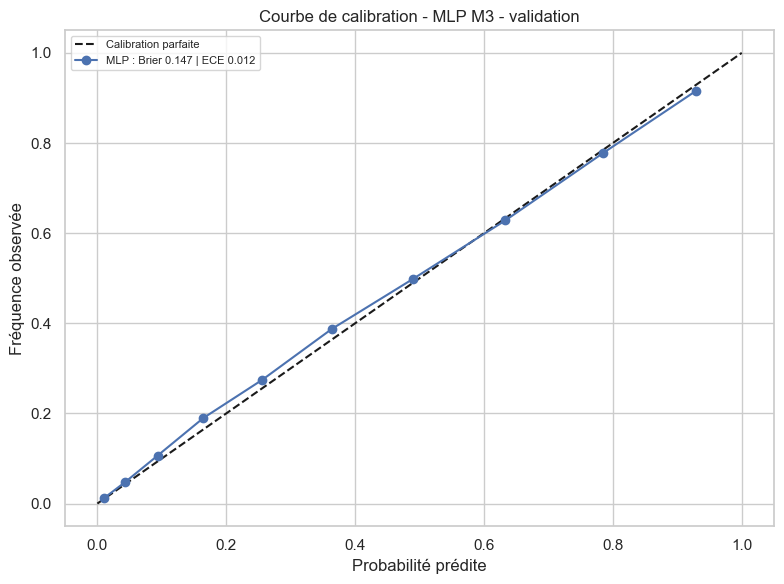

In [21]:
print("=== Calibration - Brier score sur validation - MLP M3 ===")
df_calibration, courbes_calibration = evaluer_calibration(dict_proba_val, y_val)
display(df_calibration)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
_brier_par_modele = df_calibration.set_index('Algorithme')['Brier'].to_dict()
_ece_par_modele   = (df_calibration.set_index('Algorithme')['ECE'].to_dict()
                     if 'ECE' in df_calibration.columns else {})
for nom, (xp, yp) in courbes_calibration.items():
    _b, _e = _brier_par_modele.get(nom), _ece_par_modele.get(nom)
    if _b is not None and _e is not None:
        _lab = f'{nom} : Brier {_b:.3f} | ECE {_e:.3f}'
    elif _b is not None:
        _lab = f'{nom} : Brier {_b:.3f}'
    else:
        _lab = nom
    plt.plot(xp, yp, marker='o', label=_lab)
plt.xlabel('Probabilité prédite')
plt.ylabel('Fréquence observée')
plt.title('Courbe de calibration - MLP M3 - validation', fontweight='normal')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig24_calibration_mlp_m3_sans.png', dpi=150, bbox_inches='tight')
plt.show()

# DeLong n'est pas calculé ici : il n'y a qu'un seul modèle M3 entraîné dans ce notebook.
df_delong = pd.DataFrame({'Info': ['Non applicable : un seul modèle M3 entraîné (MLP).']})


## 10. Évaluation finale sur le test interne


In [22]:
#  Évaluation finale sur le test interne, jamais utilisé pour sélectionner modèle + seuil.
#  Le seuil clinique a été choisi sur la validation, puis figé ici.

# Métriques au seuil standard 0.5
y_pred_m3_05 = (y_proba_m3_opt >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_m3_05).ravel()

se_05  = safe_div(tp, tp + fn)
sp_05  = safe_div(tn, tn + fp)
vpp_05 = safe_div(tp, tp + fp)
vpn_05 = safe_div(tn, tn + fn)
auc_final   = roc_auc_score(y_test, y_proba_m3_opt)
brier_final = brier_score_loss(y_test, y_proba_m3_opt)
bacc_final  = balanced_accuracy_score(y_test, y_pred_m3_05)

print('=' * 70)
print('MODÈLE FINAL — TEST INTERNE — MÉTRIQUES AU SEUIL 0.5')
print('=' * 70)
print(f'  Algorithme    : {algo_opt}')
print(f'  AUC           : {auc_final:.4f}')
print(f'  Brier score   : {brier_final:.4f}')
print(f'  Sensibilité   : {se_05:.4f}')
print(f'  Spécificité   : {sp_05:.4f}')
print(f'  VPP           : {vpp_05:.4f}')
print(f'  VPN           : {vpn_05:.4f}')
print(f'  Balanced Acc  : {bacc_final:.4f}')
print(f'  VP={tp:,} | VN={tn:,} | FP={fp:,} | FN={fn:,}')

# Seuil clinique figé sur la validation : application unique au test.
y_pred_m3_90 = (y_proba_m3_opt >= seuil_90).astype(int)
tn90, fp90, fn90, tp90 = confusion_matrix(y_test, y_pred_m3_90).ravel()
se_90  = safe_div(tp90, tp90 + fn90)
sp_90  = safe_div(tn90, tn90 + fp90)
vpp_90 = safe_div(tp90, tp90 + fp90)
vpn_90 = safe_div(tn90, tn90 + fn90)

print('\n=== TEST INTERNE — SEUIL CLINIQUE FIGÉ SUR VALIDATION ===')
print(f'  Seuil alerte   : {seuil_alerte:.3f}')
print(f'  Seuil fort     : {seuil_fort:.3f}')
print(f'  Sensibilité    : {se_90:.1%}')
print(f'  Spécificité    : {sp_90:.1%}')
print(f'  FP/100         : {fp90 / len(y_test) * 100:.1f}')
print(f'  FN/100         : {fn90 / len(y_test) * 100:.1f}')
print(f'  FN évités vs 0.5 : {fn - fn90:,}')
print(f'  Surcharge FP vs 0.5 : +{fp90 - fp:,}')
print(f'\nSeuils figés pour la validation temporelle : alerte={seuil_alerte:.3f} | fort={seuil_fort:.3f}')


MODÈLE FINAL — TEST INTERNE — MÉTRIQUES AU SEUIL 0.5
  Algorithme    : MLP
  AUC           : 0.8620
  Brier score   : 0.1461
  Sensibilité   : 0.6608
  Spécificité   : 0.8609
  VPP           : 0.7455
  VPN           : 0.8045
  Balanced Acc  : 0.7608
  VP=15,757 | VN=33,287 | FP=5,380 | FN=8,089

=== TEST INTERNE — SEUIL CLINIQUE FIGÉ SUR VALIDATION ===
  Seuil alerte   : 0.217
  Seuil fort     : 0.650
  Sensibilité    : 90.3%
  Spécificité    : 61.2%
  FP/100         : 24.0
  FN/100         : 3.7
  FN évités vs 0.5 : 5,775
  Surcharge FP vs 0.5 : +9,627

Seuils figés pour la validation temporelle : alerte=0.217 | fort=0.650


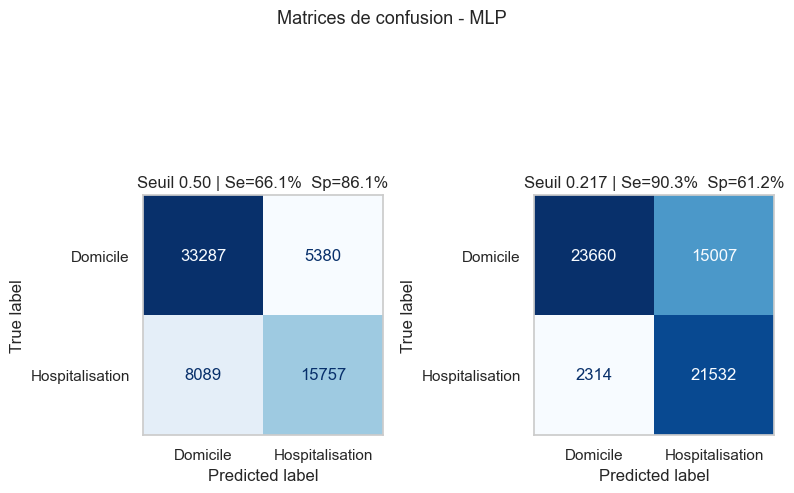

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_m3_05),
    display_labels=['Domicile', 'Hospitalisation']
).plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title(f'Seuil 0.50 | Se={se_05:.1%}  Sp={sp_05:.1%}', fontweight='normal')
axes[0].grid(False)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_m3_90),
    display_labels=['Domicile', 'Hospitalisation']
).plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='d')
axes[1].set_title(f'Seuil {seuil_90:.3f} | Se={se_90:.1%}  Sp={sp_90:.1%}', fontweight='normal')
axes[1].grid(False)

plt.suptitle(f'Matrices de confusion - {algo_opt}', fontsize=13, fontweight='normal')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig25_confusion_matrix_sans.png', dpi=150, bbox_inches='tight')
plt.show()


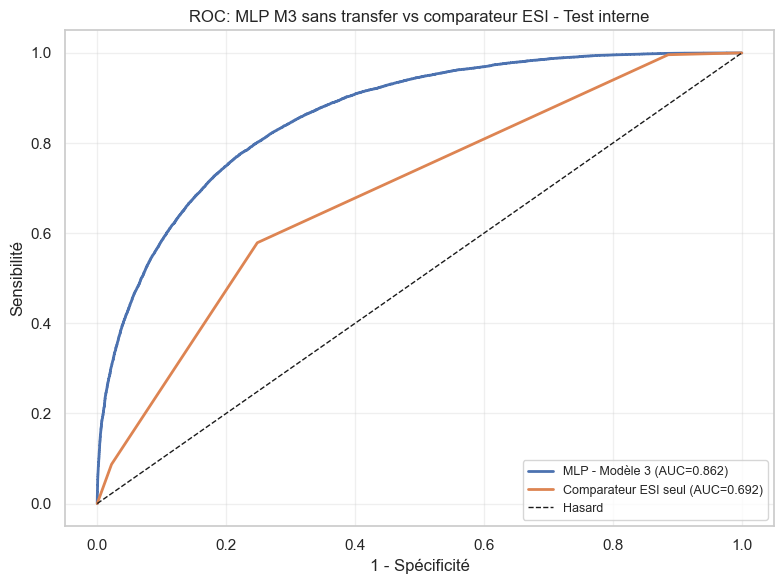

In [24]:
# Courbe ROC du MLP M3 et du comparateur ESI
out_path = FIG_DIR / "fig26_roc_mlp_m3_esi_sans.png"

# Probabilité TEST du MLP M3.
roc_models = {
    "MLP - Modèle 3": y_proba_mlp_m3_base_test,
}

# Comparateur ESI : 1 = plus grave, 5 = moins grave.
# On inverse donc le score pour que valeur élevée = risque plus élevé.
if "acuity" in df_test.columns:
    y_score_esi = 6 - pd.to_numeric(df_test["acuity"], errors="coerce")
elif "esi" in df_test.columns:
    y_score_esi = 6 - pd.to_numeric(df_test["esi"], errors="coerce")
else:
    y_score_esi = None

if y_score_esi is not None:
    roc_models["Comparateur ESI seul"] = y_score_esi

# Tracé des courbes ROC avec gestion des NaN.
y_true_all = np.asarray(y_test)

plt.figure(figsize=(8, 6))

for model_name, y_score in roc_models.items():
    y_score = np.asarray(y_score, dtype=float)

    # On retire uniquement les lignes non exploitables pour ce modèle.
    mask = np.isfinite(y_true_all) & np.isfinite(y_score)

    y_true_clean = y_true_all[mask]
    y_score_clean = y_score[mask]

    if len(np.unique(y_true_clean)) < 2:
        print(f"ROC non calculable pour {model_name} : une seule classe après filtrage.")
        continue

    fpr, tpr, _ = roc_curve(y_true_clean, y_score_clean)
    auc_model = roc_auc_score(y_true_clean, y_score_clean)
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={auc_model:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Hasard")
plt.xlabel("1 - Spécificité")
plt.ylabel("Sensibilité")
plt.title("ROC: MLP M3 sans transfer vs comparateur ESI - Test interne")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

#print(f"Figure ROC sauvegardée : {out_path.resolve()}")


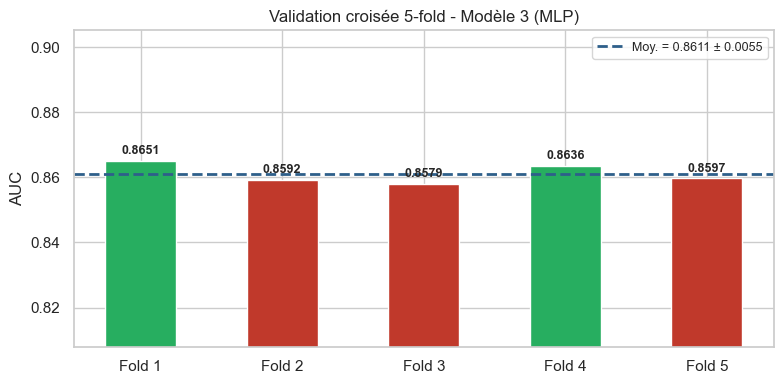

Stabilité CV (MLP) : 0.8611 ± 0.0055
  Fold 1 : 0.8651  (+0.0040)
  Fold 2 : 0.8592  (-0.0019)
  Fold 3 : 0.8579  (-0.0032)
  Fold 4 : 0.8636  (+0.0025)
  Fold 5 : 0.8597  (-0.0014)


In [25]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    clone(model_m3_opt), X_train_m3, y_train,
    cv=sgkf, groups=df_train['subject_id'], scoring='roc_auc', n_jobs=1
)

fig, ax = plt.subplots(figsize=(8, 4))
colors_cv = [VERT if s >= cv_scores.mean() else ROUGE for s in cv_scores]
ax.bar(range(1, 6), cv_scores, color=colors_cv, edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color=BLEU, lw=2, linestyle='--',
           label=f'Moy. = {cv_scores.mean():.4f} ± {2*cv_scores.std():.4f}')
for i, s in enumerate(cv_scores, 1):
    ax.text(i, s + 0.002, f'{s:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylim(max(0.5, cv_scores.min()-0.05), min(1.0, cv_scores.max()+0.04))
ax.set_ylabel('AUC')
ax.set_title(f'Validation croisée 5-fold - Modèle 3 ({algo_opt})', fontweight='normal')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig27_cv5_folds_sans.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Stabilité CV ({algo_opt}) : {cv_scores.mean():.4f} ± {2*cv_scores.std():.4f}')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i} : {s:.4f}  ({s - cv_scores.mean():+.4f})')


In [26]:
# Diagnostic overfitting — gap AUC train / test

auc_train = roc_auc_score(y_train, model_m3_opt.predict_proba(X_train_m3)[:, 1])
auc_test  = roc_auc_score(y_test,  y_proba_m3_opt)
gap       = auc_train - auc_test

if gap > 0.10:
    diagnostic = f"OVERFITTING détecté : gap = {gap:.3f}"
elif gap > 0.05:
    diagnostic = f"Gap modéré ({gap:.3f}) — surveiller"
else:
    diagnostic = f"Pas d'overfitting significatif : gap = {gap:.3f}"

print(f"AUC train : {auc_train:.4f}")
print(f"AUC test  : {auc_test:.4f}")
print(f"Gap       : {gap:.4f}")
print(f"→ {diagnostic}")


AUC train : 0.8777
AUC test  : 0.8620
Gap       : 0.0157
→ Pas d'overfitting significatif : gap = 0.016


In [27]:
metrics_final = pd.DataFrame([
    {'Modele_retenu': algo_opt, 'Jeu': 'test_interne', 'Type_seuil': 'standard_0.5', 'Seuil': 0.5,
     'AUC': auc_final, 'Brier': brier_final,
     'Se': se_05,  'Sp': sp_05,  'VPP': vpp_05,  'VPN': vpn_05,
     'VP': tp,   'VN': tn,   'FP': fp,   'FN': fn},
    {'Modele_retenu': algo_opt, 'Jeu': 'test_interne', 'Type_seuil': 'se_clin_90_val', 'Seuil': seuil_90,
     'AUC': auc_final, 'Brier': brier_final,
     'Se': se_90,  'Sp': sp_90,  'VPP': vpp_90,  'VPN': vpn_90,
     'VP': tp90, 'VN': tn90, 'FP': fp90, 'FN': fn90},
])
metrics_final['Balanced_Accuracy'] = (
    metrics_final['Se'] + metrics_final['Sp']
) / 2
metrics_final.to_csv(RESULT_DIR / 'metrics_meilleur_modele_sans_transfer.csv', index=False)
print('metrics_meilleur_modele_sans_transfer.csv sauvegardé')
display(metrics_final)


metrics_meilleur_modele_sans_transfer.csv sauvegardé


,Modele_retenu,Jeu,Type_seuil,Seuil,AUC,Brier,Se,Sp,VPP,VPN,VP,VN,FP,FN,Balanced_Accuracy
0,MLP,test_interne,standard_0.5,0.500,0.861989,0.146055,0.660782,0.860863,0.745470,0.804500,15757,33287,5380,8089,0.760822
1,MLP,test_interne,se_clin_90_val,0.217,0.861989,0.146055,0.902961,0.611891,0.589288,0.910911,21532,23660,15007,2314,0.757426


In [28]:
# Préparation du modèle final en mémoire pour la validation temporelle
# Le modèle, le scaler, l'imputer et le TF-IDF viennent des cellules précédentes.
# On ne recharge pas d'artefacts depuis le disque : le notebook suit un flux unique.

model = model_m3_opt
scaler = scaler_m3
features_baseline = list(feats_m3)
features = features_baseline
model_type = algo_opt

auc_nb04_test = float(auc_final)
auc_nb04_selection = float(best_row_opt['AUC'])
auc_nb04 = auc_nb04_test
bacc_nb04 = float(bacc_final)
brier_nb04 = float(brier_final)
valid_period = VALID_PERIOD
selection_criterion = f'Spécificité maximale sous contrainte Se >= {SE_CIBLE:.0%} sur validation interne'

train_medians = pd.Series({
    col: float(df_train[col].median())
    for col in feats_m3 if col in df_train.columns
})

meta = {
    'model_name': f'Modèle 3 — Variables structurées NB01 + NLP sans transfer ({algo_opt})',
    'algo_opt': algo_opt,
    'selection_criterion': selection_criterion,
    'feature_policy': 'Conservation de toutes les colonnes NB01 dans df ; exclusion des identifiants/dates brutes/cible/texte des prédicteurs structurés ; catégorielles NB01 encodées en dummies.',
    'nb01_columns_expected': NB01_EXPECTED_COLUMNS,
    'nb01_columns_loaded': [c for c in NB01_EXPECTED_COLUMNS if c in df.columns],
    'nb01_columns_absent': [c for c in NB01_EXPECTED_COLUMNS if c not in df.columns],
    'traceability_columns': TRACEABILITY_COLS,
    'categorical_raw_features': NB01_CATEGORICAL_RAW,
    'categorical_encoded_features': CAT_ENCODED_COLS,
    'age_variable_used': AGE_COL,
    'charlson_variable_used': CHARLSON_COL if 'CHARLSON_COL' in globals() else None,
    'charlson_priority': 'charlson_score puis charlson_score_simplifie en secours',
    'features_m1': features_m1,
    'features_m2': [f for f in features_m2 if f in df.columns],
    'features_m3': features_baseline,
    'tfidf_features': tfidf.get_feature_names_out().tolist(),
    'auc_validation_selection': auc_nb04_selection,
    'auc_final_test': auc_nb04_test,
    'balanced_accuracy_final_05': bacc_nb04,
    'brier_final_test': brier_nb04,
    'random_state': RANDOM_STATE,
    'uses_nlp': True,
    'transfer_removed_from_nlp': True,
    'text_column_used': TEXT_COL_NLP,
    'target': TARGET,
    'threshold_default': 0.5,
    'seuil_alerte': float(seuil_alerte),
    'seuil_fort': float(seuil_fort),
    'valid_period': VALID_PERIOD,
    'split_policy': 'train/validation/test patient-level disjoints dans le pool avant validation temporelle',
    'train_medians': train_medians.to_dict(),
    'structured_scaling_dtype': 'float32',
    'structured_scaling_note': 'Standardisation manuelle mémoire-sûre, paramètres appris sur le train uniquement.',
}

print('Modèle final préparé en mémoire')
print(f'Algorithme retenu : {model_type}')
print(f'Features structurées : {len(features_baseline)}')
print(f'Seuil alerte : {seuil_alerte:.3f} | seuil fort : {seuil_fort:.3f}')
print(f'Période validation temporelle : {VALID_PERIOD}')


Modèle final préparé en mémoire
Algorithme retenu : MLP
Features structurées : 31
Seuil alerte : 0.217 | seuil fort : 0.650
Période validation temporelle : 2017 - 2019


## 11. Validation temporelle


In [29]:
# Cohorte de validation temporelle
# La cohorte récente a été isolée dans la section de split et n'a pas servi à entraîner le modèle.
if len(df_valid_temp) == 0:
    raise ValueError('Validation temporelle vide — vérifier VALID_PERIOD et anchor_year_group')

# On conserve le nom y_val pour les cellules de validation temporelle qui suivent.
y_val = df_valid_temp[TARGET].values

print(f'Validation temporelle : {len(df_valid_temp):,} séjours | hospit. : {y_val.mean()*100:.1f}%')
print(f'Critère de sélection interne : {selection_criterion}')
print(f'AUC sélection interne : {auc_nb04_selection:.4f}')
print(f'AUC test interne      : {auc_nb04_test:.4f}')
print(f'Brier test interne    : {brier_nb04:.4f}')
print(f'features_baseline     : {len(features_baseline)} variables')


Validation temporelle : 67,963 séjours | hospit. : 38.9%
Critère de sélection interne : Spécificité maximale sous contrainte Se >= 90% sur validation interne
AUC sélection interne : 0.8602
AUC test interne      : 0.8620
Brier test interne    : 0.1461
features_baseline     : 31 variables


In [30]:
# Harmonisation du nom de la cohorte de validation temporelle
# Certaines cellules utilisent df_valid_temp, d'autres df_val_temp.
# On crée ici un alias unique pour éviter les erreurs de nommage.
if 'df_val_temp' not in globals():
    if 'df_valid_temp' in globals():
        df_val_temp = df_valid_temp.copy()
    elif 'df_temp' in globals():
        df_val_temp = df_temp.copy()
    elif 'df_validation_temporelle' in globals():
        df_val_temp = df_validation_temporelle.copy()
    else:
        raise NameError(
            "Aucune cohorte de validation temporelle trouvée. "
            "Vérifier que la cellule de split temporel a bien été exécutée avant celle-ci."
        )

if 'y_val' not in globals():
    y_val = df_val_temp[TARGET].values

print(f"Validation temporelle prête : {len(df_val_temp):,} séjours | prévalence {df_val_temp[TARGET].mean()*100:.1f}%")

Validation temporelle prête : 67,963 séjours | prévalence 38.9%


In [31]:
# Sécurité supplémentaire : alias validation temporelle
if 'df_val_temp' not in globals() and 'df_valid_temp' in globals():
    df_val_temp = df_valid_temp.copy()
if 'y_val' not in globals() and 'df_val_temp' in globals():
    y_val = df_val_temp[TARGET].values

#  Garde-fou : vérifications avant tout calcul (anti-bug silencieux) 
_erreurs, _alertes = [], []

# Helper local : reproduit l'encodage NB04 pour vérifier les colonnes attendues.
def _normaliser_modalite_prediction(s):
    return (
        s.fillna('missing')
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '_', regex=True)
         .str.strip('_')
         .replace('', 'missing')
    )

def _add_nb01_prediction_dummies(df_input, meta=None):
    df_out = df_input.copy()
    raw_cats = (meta or {}).get('categorical_raw_features', ['gender', 'arrival_transport'])
    for col in raw_cats:
        if col in df_out.columns:
            s = _normaliser_modalite_prediction(df_out[col])
            dummies = pd.get_dummies(s, prefix=col, dtype='int8')
            old_dummy_cols = [c for c in df_out.columns if c.startswith(f'{col}_')]
            if old_dummy_cols:
                df_out = df_out.drop(columns=old_dummy_cols)
            df_out = pd.concat([df_out, dummies], axis=1)
    return df_out

# 1) Seuils cliniques réellement présents dans les métadonnées 
if 'seuil_alerte' not in meta:
    _alertes.append(f"meta['seuil_alerte'] ABSENT -> seuil par défaut {seuil_alerte:.3f} utilisé. "
                    "Relancer NB04 corrigé pour figer le vrai seuil avant d'interpréter la validation temporelle.")
if 'seuil_fort' not in meta:
    _alertes.append(f"meta['seuil_fort'] absent -> valeur par défaut {seuil_fort:.3f}.")

# 2) Colonne texte attendue par build_X / 3) cible présente
if TEXT_COL_NLP not in df.columns:
    _erreurs.append(f"Colonne '{TEXT_COL_NLP}' absente -> build_X plantera (TF-IDF).")
if TARGET not in df.columns:
    _erreurs.append(f"Cible '{TARGET}' absente de la cohorte.")

# 4) Colonnes attendues par le scaler après reconstruction des dummies NB01.
_scaler_cols = list(getattr(scaler, 'feature_names_in_', features_baseline))
df_guard = _add_nb01_prediction_dummies(df, meta)
_manq = [c for c in _scaler_cols if c not in df_guard.columns]
if _manq:
    _alertes.append(f"{len(_manq)} colonne(s) attendue(s) par le scaler absente(s) même après encodage -> "
                    f"comblées par 0 : {[str(c) for c in _manq[:8]]}{'...' if len(_manq) > 8 else ''}")

# 5) Cohérence du nombre de features (info)
_n_attendu = len(features_baseline) + len(tfidf.get_feature_names_out())
print(f"Features attendues (structurées + TF-IDF) : {_n_attendu}")
print(f"Validation temporelle : {len(df_val_temp):,} séjours | "
      f"prévalence {df_val_temp[TARGET].mean()*100:.1f}%")
for _a in _alertes:
    print('⚠', _a)
if _erreurs:
    raise RuntimeError('Garde-fou validation temporelle (bloquant) — ' + ' | '.join(_erreurs))
print('Garde-fou : aucune erreur bloquante')

Features attendues (structurées + TF-IDF) : 1031
Validation temporelle : 67,963 séjours | prévalence 38.9%
Garde-fou : aucune erreur bloquante


In [32]:
#  Reconstruction de la matrice X comme dans NB04 
def _normaliser_modalite_prediction(s):
    return (
        s.fillna('missing')
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '_', regex=True)
         .str.strip('_')
         .replace('', 'missing')
    )

def _add_nb01_prediction_dummies(df_input, meta=None):
    """Reproduit l'encodage des variables catégorielles NB01 avant prédiction."""
    df_out = df_input.copy()
    raw_cats = (meta or {}).get('categorical_raw_features', ['gender', 'arrival_transport'])
    for col in raw_cats:
        if col in df_out.columns:
            s = _normaliser_modalite_prediction(df_out[col])
            dummies = pd.get_dummies(s, prefix=col, dtype='int8')
            old_dummy_cols = [c for c in df_out.columns if c.startswith(f'{col}_')]
            if old_dummy_cols:
                df_out = df_out.drop(columns=old_dummy_cols)
            df_out = pd.concat([df_out, dummies], axis=1)
    return df_out


def build_X(df_input, features_model, scaler, tfidf=None, imputer=None, t_medians=None):
    """Recrée les dummies NB01, aligne les colonnes, impute, scale, puis ajoute le TF-IDF."""
    df_work = _add_nb01_prediction_dummies(df_input, meta if 'meta' in globals() else None)

    scaler_cols = list(scaler.feature_names_in_) if hasattr(scaler, 'feature_names_in_') else list(features_model)
    df_scaled = df_work.reindex(columns=scaler_cols, fill_value=0)
    df_scaled = df_scaled.apply(pd.to_numeric, errors='coerce')

    if imputer is not None and hasattr(imputer, 'statistics_'):
        imp_cols = list(imputer.feature_names_in_) if hasattr(imputer, 'feature_names_in_') else scaler_cols
        # Colonnes absentes après reindex : 0 pour les dummies non observées, puis imputation pour valeurs manquantes réelles.
        df_imp = df_scaled.reindex(columns=imp_cols, fill_value=0)
        df_imp = df_imp.apply(pd.to_numeric, errors='coerce')
        X_imp = imputer.transform(df_imp)
        df_scaled = pd.DataFrame(X_imp, columns=imp_cols, index=df_scaled.index).reindex(columns=scaler_cols, fill_value=0)
    elif t_medians is not None and len(t_medians) > 0:
        for col in scaler_cols:
            if df_scaled[col].isna().any():
                df_scaled[col] = df_scaled[col].fillna(float(t_medians.get(col, df_scaled[col].median())))
    else:
        df_scaled = df_scaled.fillna(df_scaled.median(numeric_only=True))

    # Transformation mémoire-sûre : float32 + standardisation manuelle si possible.
    X_num = df_scaled[scaler_cols].to_numpy(dtype=np.float32, copy=True)
    if hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
        mean = np.asarray(scaler.mean_, dtype=np.float32)
        scale = np.asarray(scaler.scale_, dtype=np.float32)
        scale[~np.isfinite(scale) | (scale == 0)] = 1.0
        X_num -= mean
        X_num /= scale
    else:
        X_num = scaler.transform(df_scaled[scaler_cols]).astype(np.float32, copy=False)

    if tfidf is None:
        return csr_matrix(X_num, dtype=np.float32)

    X_text = tfidf.transform(df_input[TEXT_COL_NLP].fillna('')).astype(np.float32)
    return sp_hstack([csr_matrix(X_num, dtype=np.float32), X_text]).tocsr()


def predict_proba_safe(model, X):
    """Prédiction robuste en évitant la conversion dense sauf si elle est indispensable."""
    try:
        return model.predict_proba(X)[:, 1]
    except (TypeError, ValueError, MemoryError):
        if issparse(X):
            return model.predict_proba(X.toarray())[:, 1]
        return model.predict_proba(X)[:, 1]


# Test rapide
X_test_small = build_X(df_val_temp.head(10), features_baseline, scaler, tfidf, imputer, train_medians)
print(f'build_X OK - Shape : {X_test_small.shape}')

build_X OK - Shape : (10, 1031)


In [33]:
#  Prédictions sur la validation temporelle 
print('Construction de X_val...')
X_val = build_X(df_val_temp, features_baseline, scaler, tfidf, imputer, train_medians)
y_proba = predict_proba_safe(model, X_val)

print(f'X_val shape : {X_val.shape}')
print(f'y_proba — min={y_proba.min():.3f}  max={y_proba.max():.3f}  mean={y_proba.mean():.3f}')
print(f'Prévalence observée validation : {df_val_temp[TARGET].mean():.3f}')

if y_proba.mean() > 0.9 or y_proba.mean() < 0.05:
    print('⚠ Probas atypiques — vérifier cohérence du pipeline')
else:
    print('Distribution des probabilités')

feature_names = features_baseline + list(tfidf.get_feature_names_out())
print(f'Features attendues : {len(feature_names)}')


Construction de X_val...
X_val shape : (67963, 1031)
y_proba — min=0.000  max=1.000  mean=0.346
Prévalence observée validation : 0.389
Distribution des probabilités
Features attendues : 1031


In [34]:
#  Résultats principaux — validation temporelle 
def safe_div(a, b):
    return a / b if b > 0 else 0

# Le seuil clinique a été figé sur la validation interne.
# Le seuil clinique interne est appliqué tel quel à la validation temporelle.
y_pred_05 = (y_proba >= 0.5).astype(int)
y_pred = (y_proba >= seuil_alerte).astype(int)  # seuil principal pour la validation temporelle

def _metrics_at_threshold(y_true, y_score, y_hat, seuil, type_seuil):
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    se  = safe_div(tp, tp + fn)
    sp  = safe_div(tn, tn + fp)
    vpp = safe_div(tp, tp + fp)
    vpn = safe_div(tn, tn + fn)
    return {
        'Modele': model_type,
        'Type_seuil': type_seuil,
        'Seuil': seuil,
        'AUC': roc_auc_score(y_true, y_score),
        'Se': se, 'Sp': sp, 'VPP': vpp, 'VPN': vpn,
        'VP': int(tp), 'VN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'FP/100': fp / len(y_true) * 100,
        'FN/100': fn / len(y_true) * 100,
    }

m_05 = _metrics_at_threshold(y_val, y_proba, y_pred_05, 0.5, 'standard_0.5')
m_clin = _metrics_at_threshold(y_val, y_proba, y_pred, seuil_alerte, 'seuil_clinique_interne')

# Variables utilisées dans le reste du notebook = seuil clinique NB04.
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
sensibilite = m_clin['Se']
specificite = m_clin['Sp']
vpp = m_clin['VPP']
vpn = m_clin['VPN']
auc = m_clin['AUC']

delta = auc - auc_nb04 if not np.isnan(auc_nb04) else np.nan
if np.isnan(delta):
    interpretation = 'comparaison NB04 non disponible'
elif abs(delta) < 0.03:
    interpretation = 'stabilité acceptable'
elif delta > 0.03:
    interpretation = 'performance supérieure — vérifier indépendance'
else:
    interpretation = 'dégradation temporelle à documenter'

print('=' * 65)
print('RÉSULTATS — VALIDATION TEMPORELLE')
print('=' * 65)
print(f'Modèle       : {model_type}')
print(f'AUC          : {auc:.4f}')
print(f'Seuil clinique interne : {seuil_alerte:.3f}')
print(f'Sensibilité  : {sensibilite:.4f}')
print(f'Spécificité  : {specificite:.4f}')
print(f'VPP          : {vpp:.4f}')
print(f'VPN          : {vpn:.4f}')
print(f'VP={tp:,} | VN={tn:,} | FP={fp:,} | FN={fn:,}')
print(f'FP/100={m_clin["FP/100"]:.1f} | FN/100={m_clin["FN/100"]:.1f}')
print(f'AUC test interne : {auc_nb04:.4f}' if not np.isnan(auc_nb04) else '  AUC test interne : non disponible')
print(f'Δ AUC                 : {delta:+.4f} → {interpretation}' if not np.isnan(delta) else f'  Δ AUC                 : {interpretation}')

print('\nRéférence au seuil 0,5, conservée seulement pour comparaison :')
print(f'Se={m_05["Se"]:.4f} | Sp={m_05["Sp"]:.4f} | FP/100={m_05["FP/100"]:.1f} | FN/100={m_05["FN/100"]:.1f}')

pd.DataFrame([m_05, m_clin]).to_csv(RESULT_DIR / 'metrics_validation_temporelle_sans_transfer.csv', index=False)
print('\n metrics_validation_temporelle_sans_transfer.csv sauvegardé avec seuil 0,5 + seuil clinique')


RÉSULTATS — VALIDATION TEMPORELLE
Modèle       : MLP
AUC          : 0.8842
Seuil clinique interne : 0.217
Sensibilité  : 0.8765
Spécificité  : 0.7045
VPP          : 0.6540
VPN          : 0.8995
VP=23,186 | VN=29,245 | FP=12,265 | FN=3,267
FP/100=18.0 | FN/100=4.8
AUC test interne : 0.8620
Δ AUC                 : +0.0222 → stabilité acceptable

Référence au seuil 0,5, conservée seulement pour comparaison :
Se=0.6417 | Sp=0.9030 | FP/100=5.9 | FN/100=13.9

 metrics_validation_temporelle_sans_transfer.csv sauvegardé avec seuil 0,5 + seuil clinique


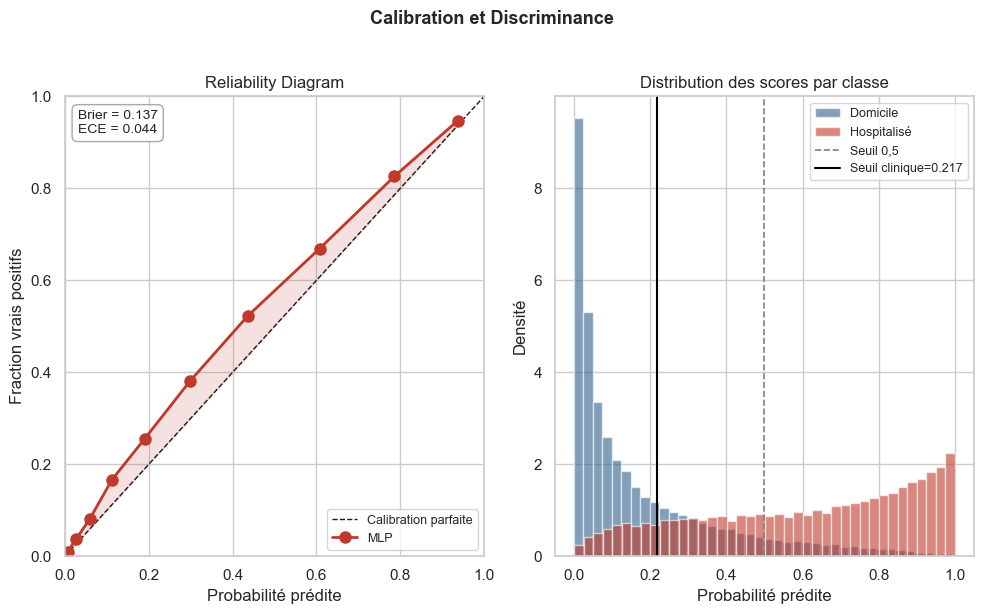

Score de Brier : 0.1366  (0=parfait | 0.25≈référence grossière si prévalence équilibrée)
ECE déciles : 0.0436
Calibration : Acceptable


,decile,n,proba_moyenne,taux_observe,ecart
0,"(-0.0009861, 0.014]",6797,0.006032,0.008975,-0.002942
1,"(0.014, 0.0394]",6796,0.025965,0.036933,-0.010968
2,"(0.0394, 0.0812]",6796,0.058435,0.079900,-0.021465
3,"(0.0812, 0.145]",6796,0.111723,0.165980,-0.054257
4,"(0.145, 0.24]",6797,0.190168,0.255554,-0.065386
5,"(0.24, 0.362]",6796,0.297662,0.380224,-0.082562
6,"(0.362, 0.516]",6796,0.435757,0.522366,-0.086609
7,"(0.516, 0.699]",6796,0.607483,0.669070,-0.061587
8,"(0.699, 0.867]",6796,0.785665,0.825927,-0.040262
9,"(0.867, 1.0]",6797,0.937197,0.947330,-0.010133


tab3_calibration_deciles_avec.csv sauvegardé


In [35]:
# Métriques de calibration calculées AVANT le tracé, afin d'être annotées sur la figure.
brier = brier_score_loss(y_val, y_proba)
_calib_pre = pd.DataFrame({'y_true': y_val, 'y_proba': y_proba})
_calib_pre['decile'] = pd.qcut(_calib_pre['y_proba'], 10, duplicates='drop')
_agg_pre = (_calib_pre.groupby('decile', observed=True)
            .agg(n=('y_true', 'size'),
                 proba_moyenne=('y_proba', 'mean'),
                 taux_observe=('y_true', 'mean')))
ece = float((_agg_pre['n'] * (_agg_pre['taux_observe'] - _agg_pre['proba_moyenne']).abs()).sum()
            / _agg_pre['n'].sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

prob_true, prob_pred = calibration_curve(y_val, y_proba, n_bins=10, strategy='quantile')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Calibration parfaite')
axes[0].plot(prob_pred, prob_true, 'o-', lw=2, color='#C0392B', markersize=8,
             label=model_type)
axes[0].fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color='#C0392B')
axes[0].set(xlabel='Probabilité prédite', ylabel='Fraction vrais positifs',
            title='Reliability Diagram', xlim=[0,1], ylim=[0,1])
axes[0].legend(fontsize=9)
axes[0].text(0.03, 0.97, f'Brier = {brier:.3f}\nECE = {ece:.3f}',
             transform=axes[0].transAxes, va='top', ha='left', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       alpha=0.85, edgecolor='#999999'))

for tgt, color, label in [(0,'#2E5F8A','Domicile'), (1,'#C0392B','Hospitalisé')]:
    axes[1].hist(y_proba[y_val==tgt], bins=40, alpha=0.6, color=color,
                 edgecolor='white', density=True, label=label)
axes[1].axvline(0.5, color='grey', linestyle='--', lw=1.2, label='Seuil 0,5')
axes[1].axvline(seuil_alerte, color='black', linestyle='-', lw=1.5, label=f'Seuil clinique={seuil_alerte:.3f}')
axes[1].set(xlabel='Probabilité prédite', ylabel='Densité',
            title='Distribution des scores par classe')
axes[1].legend(fontsize=9)

plt.suptitle('Calibration et Discriminance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig29_calibration_sans.png', dpi=150, bbox_inches='tight')
plt.show()

brier = brier_score_loss(y_val, y_proba)
print(f'Score de Brier : {brier:.4f}  (0=parfait | 0.25≈référence grossière si prévalence équilibrée)')

# Table de calibration par déciles : indispensable si l'application affiche une probabilité.
calib_df = pd.DataFrame({'y_true': y_val, 'y_proba': y_proba})
calib_df['decile'] = pd.qcut(calib_df['y_proba'], 10, duplicates='drop')

table_calib = (
    calib_df.groupby('decile', observed=True)
    .agg(
        n=('y_true', 'size'),
        proba_moyenne=('y_proba', 'mean'),
        taux_observe=('y_true', 'mean')
    )
    .reset_index()
)
table_calib['ecart'] = table_calib['proba_moyenne'] - table_calib['taux_observe']

ece = (table_calib['n'] * table_calib['ecart'].abs()).sum() / table_calib['n'].sum()
print(f'ECE déciles : {ece:.4f}')
print('Calibration : ' + ('Acceptable' if (brier < 0.15 and ece < 0.05) else 'À vérifier'))

display(table_calib)
table_calib.to_csv(RESULT_DIR / 'tab23_calibration_deciles_sans.csv', index=False)
print('tab3_calibration_deciles_avec.csv sauvegardé')


In [36]:
# Recalibration Platt (sigmoid) — exploration locale 
# cette cellule ajuste Platt sur la validation temporelle elle-même.
# Elle sert uniquement à documenter la calibration locale.
# Les métriques principales de validation ne doivent pas être recalculées
# sur ces probabilités ajustées, car cela utiliserait les labels de validation.

needs_calibration = (brier >= 0.15 or ece >= 0.05)

if needs_calibration:
    print('** Calibration insuffisante — application de la correction Platt')

    # Platt scaling manuel : régression logistique sur les scores bruts
    from sklearn.linear_model import LogisticRegression as _LR
    _platt = _LR(max_iter=1000, random_state=RANDOM_STATE)
    _platt.fit(y_proba.reshape(-1, 1), y_val)

    y_proba_cal = _platt.predict_proba(y_proba.reshape(-1, 1))[:, 1]
    calibrator  = _platt  # conservé pour la sauvegarde

    #  Métriques après calibration 
    brier_cal = brier_score_loss(y_val, y_proba_cal)
    prob_true_cal, prob_pred_cal = calibration_curve(
        y_val, y_proba_cal, n_bins=10, strategy='quantile'
    )

    calib_df_cal = pd.DataFrame({'y_true': y_val, 'y_proba': y_proba_cal})
    calib_df_cal['decile'] = pd.qcut(calib_df_cal['y_proba'], 10, duplicates='drop')
    table_calib_cal = (
        calib_df_cal.groupby('decile', observed=True)
        .agg(n=('y_true','size'), proba_moyenne=('y_proba','mean'), taux_observe=('y_true','mean'))
        .reset_index()
    )
    table_calib_cal['ecart'] = table_calib_cal['proba_moyenne'] - table_calib_cal['taux_observe']
    ece_cal = (table_calib_cal['n'] * table_calib_cal['ecart'].abs()).sum() / table_calib_cal['n'].sum()

    #  Figure comparative avant / après 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot([0,1],[0,1],'k--',lw=1, label='Calibration parfaite')
    axes[0].plot(prob_pred,     prob_true,     'o-', lw=2, color='#C0392B',
                 markersize=7, label=f'Avant (ECE={ece:.4f})')
    axes[0].plot(prob_pred_cal, prob_true_cal, 's-', lw=2, color='#27AE60',
                 markersize=7, label=f'Après Platt (ECE={ece_cal:.4f})')
    axes[0].fill_between(prob_pred_cal, prob_pred_cal, prob_true_cal,
                          alpha=0.12, color='#27AE60')
    axes[0].set(xlabel='Probabilité prédite', ylabel='Fraction observée',
                title='Reliability Diagram — avant vs après Platt',
                xlim=[0,1], ylim=[0,1])
    axes[0].legend(fontsize=9)

    axes[1].bar(['Avant Platt', 'Après Platt'], [brier, brier_cal],
                color=['#C0392B','#27AE60'], edgecolor='white', width=0.4)
    axes[1].axhline(0.15, color='grey', linestyle='--', lw=1,
                    label='Seuil acceptable (0.15)')
    axes[1].set_ylabel('Score de Brier')
    axes[1].set_title('Amélioration du Brier score')
    axes[1].legend(fontsize=9)
    for j, v in enumerate([brier, brier_cal]):
        axes[1].text(j, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
    plt.suptitle(f'Recalibration Platt — {model_type}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig28_calibration_platt_sans.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Brier avant : {brier:.4f}  →  après : {brier_cal:.4f}  (Δ={brier_cal-brier:+.4f})')
    print(f'ECE   avant : {ece:.4f}   →  après : {ece_cal:.4f}   (Δ={ece_cal-ece:+.4f})')
    verdict = 'Acceptable' if (brier_cal < 0.15 and ece_cal < 0.05) else 'Toujours imparfaite — documenter dans les limites'
    print(f'Verdict : {verdict}')

    # Sauvegarde uniquement exploratoire : ne pas utiliser comme modèle final.
    table_calib_cal.to_csv(RESULT_DIR / 'tab24_calibration_deciles_platt_sans.csv', index=False)
    print('tab5_calibration_deciles_platt_avec.csv sauvegardé')
    print('Aucun modèle calibré n’est sauvegardé ici : utiliser un jeu de calibration séparé, comme dans NB05.')

else:
    print('Calibration acceptable — recalibration Platt non nécessaire')
    calibrator  = None
    brier_cal   = brier
    ece_cal     = ece
    y_proba_cal = y_proba.copy()


Calibration acceptable — recalibration Platt non nécessaire


In [37]:
# Conservation des probabilités non calibrées pour la validation
# On ne remplace pas y_proba par y_proba_cal ici.
# y_proba_cal est issu d'une recalibration exploratoire ajustée sur la validation
# temporelle elle-même ; l'utiliser pour les métriques principales serait optimiste.

y_proba_validation = y_proba.copy()
y_pred = (y_proba_validation >= seuil_alerte).astype(int)

# Recalcul des métriques principales avec les probabilités non recalibrées
# et le seuil clinique figé sur la validation interne.
auc = roc_auc_score(y_val, y_proba_validation)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
sensibilite = safe_div(tp, tp + fn)
specificite = safe_div(tn, tn + fp)
vpp = safe_div(tp, tp + fp)
vpn = safe_div(tn, tn + fn)

label_cal = f'(non recalibré ; seuil clinique interne={seuil_alerte:.3f})'
print(f'Métriques de validation temporelle {label_cal} :')
print(f'AUC={auc:.4f}  Se={sensibilite:.4f}  Sp={specificite:.4f}  FP/100={fp/len(y_val)*100:.1f}  FN/100={fn/len(y_val)*100:.1f}')


Métriques de validation temporelle (non recalibré ; seuil clinique interne=0.217) :
AUC=0.8842  Se=0.8765  Sp=0.7045  FP/100=18.0  FN/100=4.8


### 11.1 Sauvegarde des prédictions individuelles pour les courbes ROC

In [38]:
# Sauvegarde des prédictions individuelles — modèle sans transfer
# Ces fichiers sont nécessaires pour tracer de vraies courbes ROC dans le
# notebook de comparaison. Une courbe ROC ne peut pas être reconstruite à partir
# des métriques agrégées seules : il faut y_true et y_proba pour chaque séjour.

RESULT_DIR.mkdir(parents=True, exist_ok=True)

def _col_or_range(df_source, col, n):
    if col in df_source.columns:
        return df_source[col].values
    return np.arange(n)

# Test interne
_y_true_test = np.asarray(y_test, dtype=int)
_y_proba_test = np.asarray(y_proba_m3_opt, dtype=float)

if len(_y_true_test) != len(_y_proba_test):
    raise ValueError(
        f"Incohérence test interne : len(y_test)={len(_y_true_test)} "
        f"mais len(y_proba_m3_opt)={len(_y_proba_test)}"
    )

pred_test_sans_transfer = pd.DataFrame({
    "Modele_comparaison": "Sans transfer",
    "Jeu_standardise": "Test interne",
    "subject_id": _col_or_range(df_test, "subject_id", len(df_test)),
    "stay_id": _col_or_range(df_test, "stay_id", len(df_test)),
    "y_true": _y_true_test,
    "y_proba": _y_proba_test
})

# Validation temporelle
_df_val_temp = df_val_temp if "df_val_temp" in globals() else df_valid_temp
_y_true_temp = np.asarray(y_val, dtype=int)
_y_proba_temp = np.asarray(
    y_proba_validation if "y_proba_validation" in globals() else y_proba,
    dtype=float
)

if len(_y_true_temp) != len(_y_proba_temp):
    raise ValueError(
        f"Incohérence validation temporelle : len(y_val)={len(_y_true_temp)} "
        f"mais len(y_proba_validation/y_proba)={len(_y_proba_temp)}"
    )

pred_temp_sans_transfer = pd.DataFrame({
    "Modele_comparaison": "Sans transfer",
    "Jeu_standardise": "Validation temporelle",
    "subject_id": _col_or_range(_df_val_temp, "subject_id", len(_df_val_temp)),
    "stay_id": _col_or_range(_df_val_temp, "stay_id", len(_df_val_temp)),
    "y_true": _y_true_temp,
    "y_proba": _y_proba_temp
})

predictions_sans_transfer = pd.concat(
    [pred_test_sans_transfer, pred_temp_sans_transfer],
    ignore_index=True
)

out_pred_sans = RESULT_DIR / "predictions_individuelles_sans_transfer.csv"
predictions_sans_transfer.to_csv(out_pred_sans, index=False)

#print(f"Prédictions individuelles sauvegardées : {out_pred_sans}")
print(predictions_sans_transfer.groupby(["Modele_comparaison", "Jeu_standardise"]).size())

Modele_comparaison  Jeu_standardise      
Sans transfer       Test interne             62513
                    Validation temporelle    67963
dtype: int64


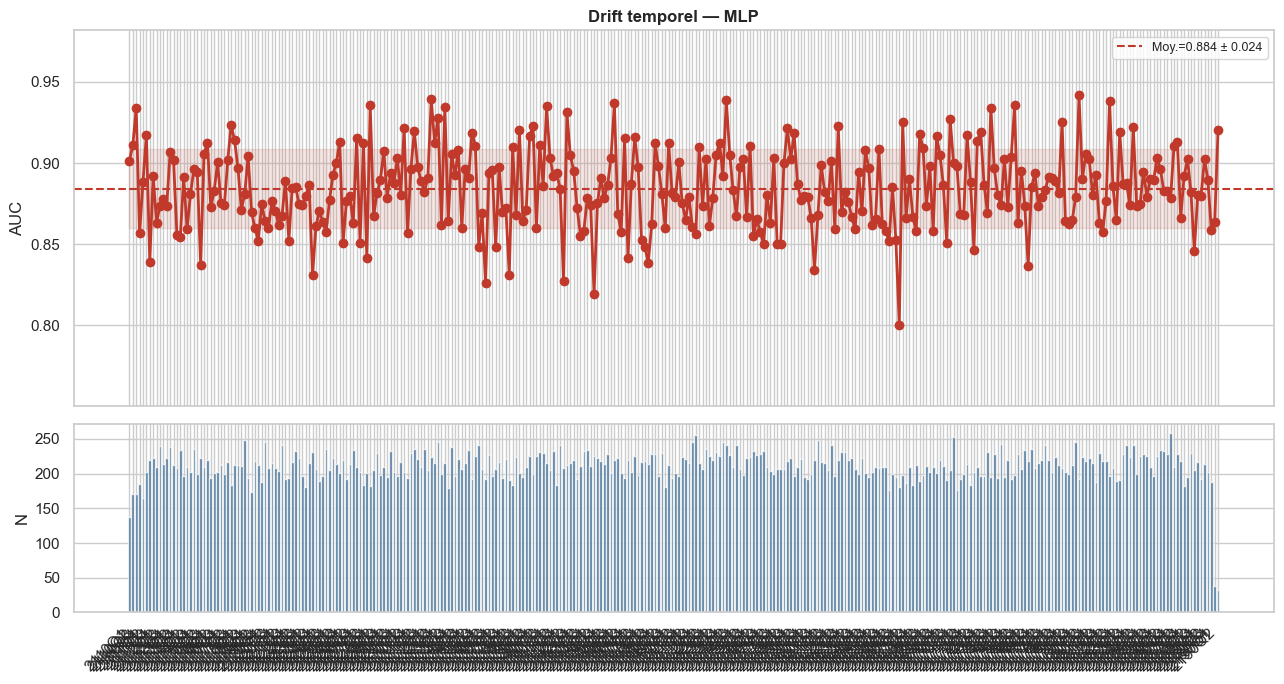

tab11_auc_trimestrielle_avec.csv sauvegardé


In [39]:
#  Stabilité temporelle par trimestre 
if 'intime' not in df_val_temp.columns:
    print('intime absent — drift non disponible')
else:
    df_drift = df_val_temp.copy()
    df_drift['intime']  = pd.to_datetime(df_drift['intime'], errors='coerce')
    df_drift['quarter'] = df_drift['intime'].dt.to_period('Q')
    df_drift['yp'] = predict_proba_safe(model, build_X(df_drift, features_baseline, scaler, tfidf, imputer, train_medians))

    rows = [{'q': str(p), 'n': len(g), 'auc': roc_auc_score(g[TARGET], g['yp'])}
            for p, g in df_drift.groupby('quarter')
            if g[TARGET].nunique() == 2 and len(g) >= 30]
    dq = pd.DataFrame(rows)

    if len(dq) == 0:
        print('Aucun trimestre exploitable pour le drift')
    else:
        x = range(len(dq))
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                        gridspec_kw={'height_ratios': [2, 1]})
        ax1.plot(x, dq['auc'], 'o-', color='#C0392B', lw=2, markersize=6)
        ax1.axhline(dq['auc'].mean(), color='#C0392B', lw=1.5, linestyle='--',
                    label=f'Moy.={dq["auc"].mean():.3f} ± {dq["auc"].std():.3f}')
        ax1.fill_between(x, dq['auc'].mean()-dq['auc'].std(),
                            dq['auc'].mean()+dq['auc'].std(), alpha=0.12, color='#C0392B')
        ax1.set_ylim(max(0.5, dq['auc'].min()-0.05), min(1.0, dq['auc'].max()+0.04))
        ax1.set_ylabel('AUC')
        ax1.set_title(f'Drift temporel — {model_type}', fontweight='bold')
        ax1.legend(fontsize=9)

        ax2.bar(x, dq['n'], color='#2E5F8A', alpha=0.75)
        ax2.set_ylabel('N')
        ax2.set_xticks(list(x))
        ax2.set_xticklabels(dq['q'], rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig30_drift_temporel_sans.png', dpi=150, bbox_inches='tight')
        plt.show()

        dq.to_csv(RESULT_DIR / 'tab25_auc_trimestrielle_sans.csv', index=False)
        print('tab11_auc_trimestrielle_avec.csv sauvegardé')


## 12. Interprétabilité


In [40]:
# Interprétabilité : approche adaptée au modèle retenu 
# On garde une stratégie robuste :
#   1. importance globale rapide sur toutes les variables ;
#   2. SHAP model-agnostic sur les variables structurées uniquement ;
#   3. importance des termes NLP à partir de l'importance globale.

for _var in ['features_baseline', 'tfidf', 'model', 'X_val', 'y_val',
             'scaler', 'imputer', 'feature_names']:
    if _var not in dir():
        raise NameError(f"'{_var}' non défini — exécuter Kernel > Run All Above.")

feature_names = features_baseline + list(tfidf.get_feature_names_out())
if X_val.shape[1] != len(feature_names):
    raise ValueError(f'X_val={X_val.shape[1]} vs feature_names={len(feature_names)}')

model_class = type(model).__name__
TFIDF_START = len(features_baseline)
rng = np.random.default_rng(RANDOM_STATE)
INTERP_MODE = 'shap'

print(f'Modèle interprété : {model_class} ({model_type})')


Modèle interprété : MLPClassifier (MLP)


In [41]:
# Étape 1 : Importance globale rapide — toutes features 
print('\nÉtape 1 — Importance globale rapide...')

if model_class in ['RandomForestClassifier', 'XGBClassifier']:
    imp = model.feature_importances_
    imp_type = 'Gini (MDI)' if model_class == 'RandomForestClassifier' else 'Gain moyen'
elif model_class == 'LogisticRegression':
    imp = np.abs(model.coef_[0])
    imp_type = '|Coefficient|'
elif model_class == 'MLPClassifier':
    # Approximation rapide : poids absolus entre la couche d'entrée et la 1re couche cachée.
    # Ce n'est pas un SHAP global ; cela sert à repérer les variables/termes les plus utilisés par le réseau.
    imp = np.mean(np.abs(model.coefs_[0]), axis=1)
    imp_type = 'Poids entrée MLP |W| — proxy descriptif'
else:
    raise ValueError(f"'{model_class}' non supporté pour l'importance globale rapide.")

if len(imp) != len(feature_names):
    raise ValueError(f'Importance={len(imp)} vs feature_names={len(feature_names)}')

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': imp,
    'type': ['NLP' if i >= TFIDF_START else 'Clinique' for i in range(len(feature_names))],
    'methode': imp_type,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.to_csv(RESULT_DIR / 'tab26_importance_globale_sans.csv', index=False)
print(f'  Méthode      : {imp_type}')
print(f'  Top 5 global : {importance_df["feature"].head().tolist()}')
print('tab12_importance_globale_avec.csv sauvegardé')


Étape 1 — Importance globale rapide...
  Méthode      : Poids entrée MLP |W| — proxy descriptif
  Top 5 global : ['rci', 'jaundice', 'pancreatitis', 'gib', 'status fever']
tab12_importance_globale_avec.csv sauvegardé


In [42]:
# Étape 2 : SHAP sur features STRUCTURÉES uniquement 
# TreeExplainer sur la matrice complète (1017 features) est trop lent.
# On calcule les valeurs SHAP sur la sous-matrice structurée uniquement.
# Méthode : PermutationExplainer (model-agnostic, pas de wrapper biaisé).
# Les features NLP sont couvertes par l'importance globale rapide (étape 1).
print('\nÉtape 2 — SHAP PermutationExplainer sur features structurées...')

N_SHAP       = min(500, X_val.shape[0])
idx_shap     = rng.choice(X_val.shape[0], size=N_SHAP, replace=False)
X_shap_full  = X_val[idx_shap].toarray() if issparse(X_val) else np.asarray(X_val[idx_shap])
X_shap_struct = X_shap_full[:, :TFIDF_START]
X_shap_df     = pd.DataFrame(X_shap_struct, columns=features_baseline)
y_shap        = np.asarray(y_val)[idx_shap]

# PermutationExplainer : perturbe chaque feature et mesure la chute de performance
# Appliqué directement sur le modèle complet via une fonction de prédiction
# qui reconstruit la matrice complète (structurées + TF-IDF zéro).
# Cela donne les SHAP marginaux corrects pour les features structurées.
def _predict_with_struct(X_struct_arr):
    """Reconstruit X complet avec TF-IDF=0 pour les features structurées seules."""
    n = X_struct_arr.shape[0]
    X_full = np.zeros((n, TFIDF_START + (X_val.shape[1] - TFIDF_START)))
    X_full[:, :TFIDF_START] = X_struct_arr
    return predict_proba_safe(model, csr_matrix(X_full))

explainer_struct = shap.Explainer(
    _predict_with_struct,
    X_shap_df,
    feature_names=features_baseline,
    algorithm='permutation',
    max_evals=2 * len(features_baseline) + 1
)
shap_out    = explainer_struct(X_shap_df)
shap_values = np.asarray(shap_out.values)
if shap_values.ndim == 3: shap_values = shap_values[:, :, 1]

feature_names_shap = features_baseline

print(f'SHAP calculé  — shape : {shap_values.shape} ({N_SHAP} séjours)')
print(f'Features SHAP : {feature_names_shap}')
print('Note : importance NLP dans tab12_importance_globale_avec.csv (étape 1)')



Étape 2 — SHAP PermutationExplainer sur features structurées...


PermutationExplainer explainer: 501it [00:37, 11.90it/s]                         

SHAP calculé  — shape : (500, 31) (500 séjours)
Features SHAP : ['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'pain', 'age_ed', 'acuity', 'n_hosp_anterieures', 'hour', 'charlson_score', 'cm_dm_sans_complic', 'cm_dm_avec_complic', 'cm_insuffisance_card', 'cm_bpco', 'cm_insuffisance_renale', 'cm_cancer', 'cm_cancer_meta', 'cm_infarctus', 'cm_avc', 'cm_demence', 'cm_maladie_foie', 'cm_vih_sida', 'gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Note : importance NLP dans tab12_importance_globale_avec.csv (étape 1)


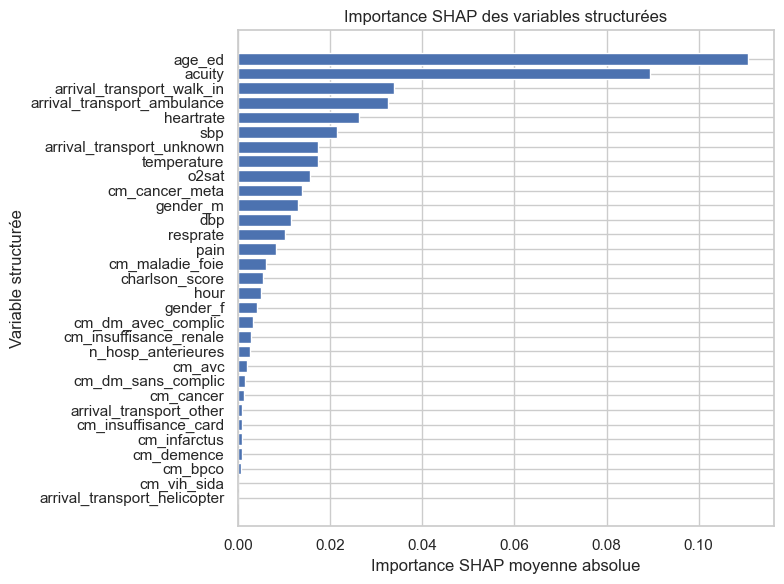

In [43]:
#  Visualisation SHAP — features structurées 
# Cette cellule utilise les valeurs SHAP déjà calculées dans la cellule précédente.


# Vérification de cohérence
assert shap_values.shape[1] == len(feature_names_shap), (
    "Le nombre de colonnes SHAP ne correspond pas au nombre de features."
)

# ---------------------------------------------------------------------
# 1. Barplot SHAP : importance moyenne absolue des variables structurées
# ---------------------------------------------------------------------

shap_importance = (
    pd.DataFrame({
        "Variable": feature_names_shap,
        "Importance_SHAP_moyenne": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("Importance_SHAP_moyenne", ascending=True)
)

plt.figure(figsize=(8, 6))
plt.barh(
    shap_importance["Variable"],
    shap_importance["Importance_SHAP_moyenne"]
)
plt.xlabel("Importance SHAP moyenne absolue")
plt.ylabel("Variable structurée")
plt.title("Importance SHAP des variables structurées")
plt.tight_layout()

out_bar = FIG_DIR / "fig31_shap_importance_struct_sans.png"
plt.savefig(out_bar, dpi=300, bbox_inches="tight")
plt.show()

#print(f"Figure sauvegardée : {out_bar.resolve()}")

### 12.1 Importance globale


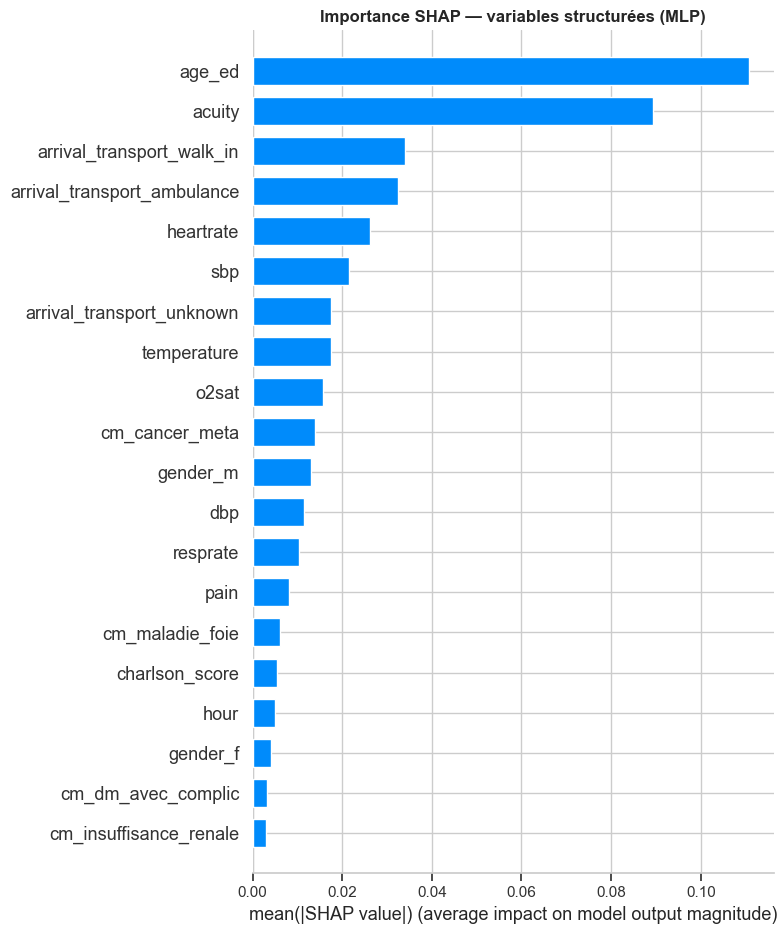

In [44]:
#  Importance SHAP des variables structurées
if INTERP_MODE == 'shap':
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap_df, plot_type='bar', max_display=20, show=False)
    plt.title(f'Importance SHAP — variables structurées ({model_type})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig32_shap_global_sans.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    top20 = importance_df.head(20).sort_values('importance')
    colors = ['#C0392B' if t == 'NLP' else '#2E5F8A' for t in top20['type']]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top20['feature'], top20['importance'], color=colors, edgecolor='white')
    ax.set_xlabel('Importance globale')
    ax.set_title(f'Importance globale — {model_type}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig33_importance_global_sans.png', dpi=150, bbox_inches='tight')
    plt.show()

### 12.2 Direction et magnitude


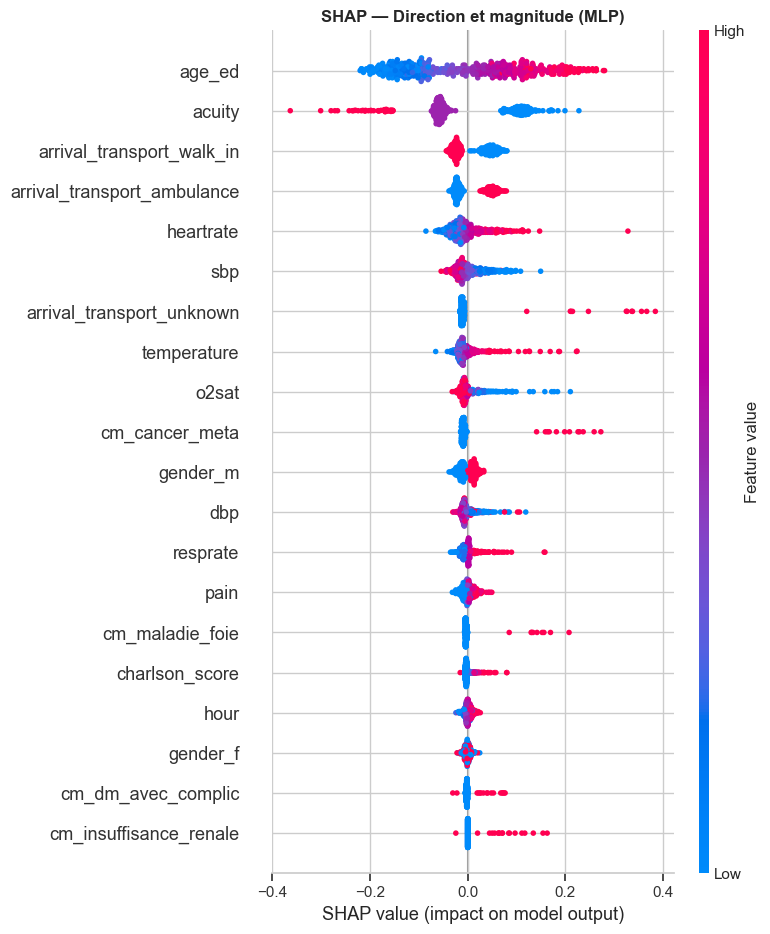

In [45]:
#  Direction et magnitude 
if INTERP_MODE == 'shap':
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_shap_df, max_display=20, show=False)
    plt.title(f'SHAP — Direction et magnitude ({model_type})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig34_shap_density_sans.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Direction SHAP non calculée pour ce modèle non linéaire.')
    print('Pour le MLP, le notebook utilise une importance globale par permutation.')


### 12.3 Top termes NLP


In [46]:
#  Top termes NLP
# shap_values couvre les variables structurées ; l'importance des termes NLP
# vient de l'importance globale rapide calculée à l'étape 1.
top_nlp = (
    importance_df[importance_df['type'] == 'NLP']
    [['feature', 'importance', 'methode']]
    .rename(columns={'feature': 'Terme', 'importance': 'Importance', 'methode': 'Méthode'})
    .assign(Contribution_moyenne=np.nan)  # signe non disponible pour cette importance globale
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('=== Top 15 termes NLP les plus influents ===')
display(top_nlp)
top_nlp.to_csv(RESULT_DIR / 'tab27_top_termes_nlp_sans.csv', index=False)
print('tab13_top_termes_nlp_avec.csv sauvegardé')

=== Top 15 termes NLP les plus influents ===


,Terme,Importance,Méthode,Contribution_moyenne
0,rci,0.237635,Poids entrée MLP |W| — proxy descriptif,NaN
1,jaundice,0.236380,Poids entrée MLP |W| — proxy descriptif,NaN
2,pancreatitis,0.229995,Poids entrée MLP |W| — proxy descriptif,NaN
3,gib,0.227690,Poids entrée MLP |W| — proxy descriptif,NaN
4,status fever,0.225313,Poids entrée MLP |W| — proxy descriptif,NaN
5,appendicitis,0.214438,Poids entrée MLP |W| — proxy descriptif,NaN
6,needlestick,0.205642,Poids entrée MLP |W| — proxy descriptif,NaN
7,sepsis,0.201532,Poids entrée MLP |W| — proxy descriptif,NaN
8,nstemi,0.198805,Poids entrée MLP |W| — proxy descriptif,NaN
9,pain anxiety,0.196517,Poids entrée MLP |W| — proxy descriptif,NaN


tab13_top_termes_nlp_avec.csv sauvegardé


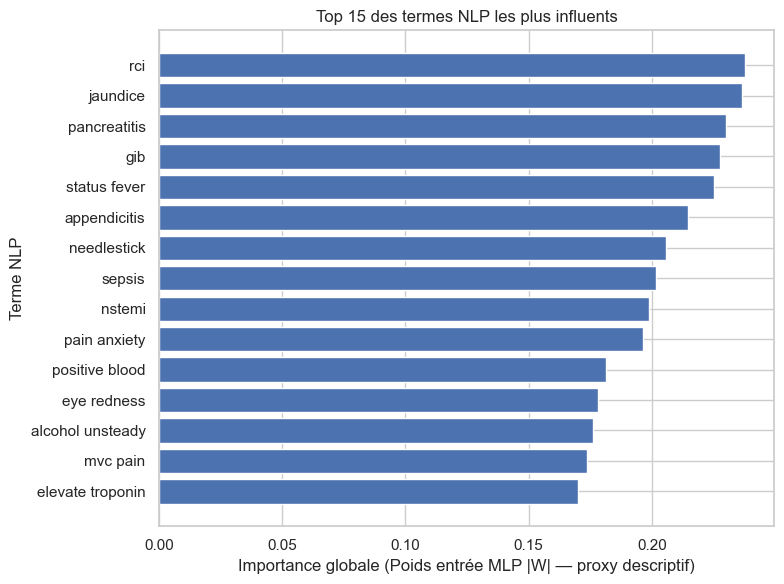

In [47]:
#  Figure : Top termes NLP selon l'importance globale
# Utilise le tableau top_nlp déjà créé ci-dessus.
FIG_DIR.mkdir(parents=True, exist_ok=True)

top_nlp_plot = top_nlp.sort_values("Importance", ascending=True)
methode_nlp = top_nlp["Méthode"].iloc[0] if len(top_nlp) > 0 else "Importance globale"

plt.figure(figsize=(8, 6))

plt.barh(
    top_nlp_plot["Terme"],
    top_nlp_plot["Importance"]
)

plt.xlabel(f"Importance globale ({methode_nlp})")
plt.ylabel("Terme NLP")
plt.title("Top 15 des termes NLP les plus influents")

plt.tight_layout()

out_path = FIG_DIR / "fig35_top15_termes_nlp_sans.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

#print(f"Figure sauvegardée : {out_path.resolve()}")

### 12.4 Explication locale — patient individuel


Motif de consultation utilisé par le NLP : confusion hallucination
P(hospit.) = 68.89% | Réel : 1


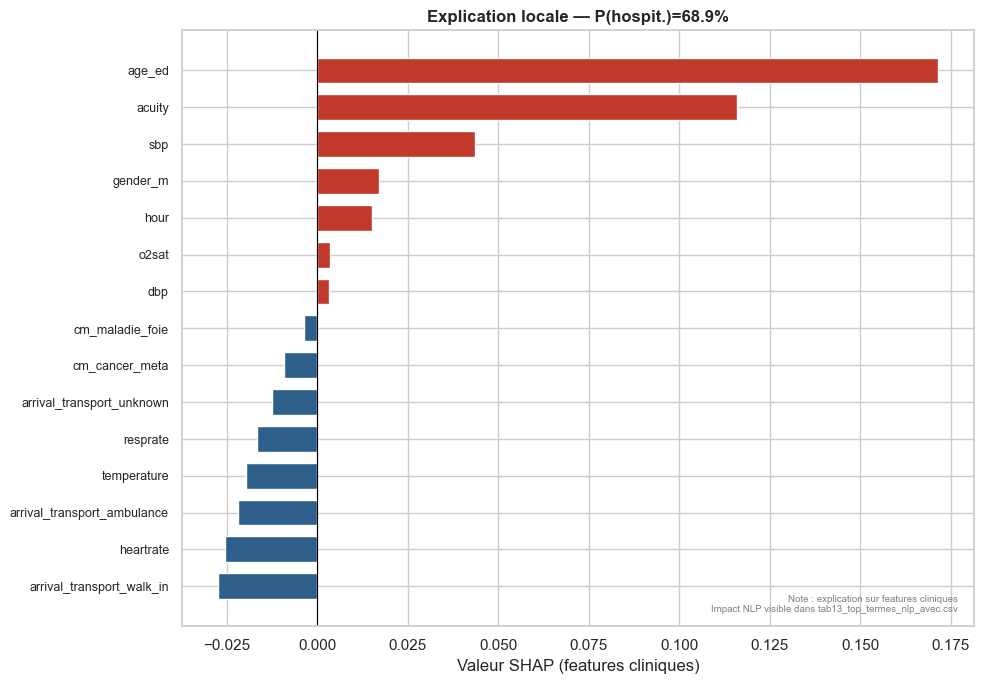

In [48]:
# Explication locale d'un patient hospitalisé 
idx_hosp   = df_val_temp[df_val_temp[TARGET] == 1].index[0]
patient_row = df_val_temp.loc[[idx_hosp]]
X_patient   = build_X(patient_row, features_baseline, scaler, tfidf, imputer, train_medians)
prob_hosp   = predict_proba_safe(model, X_patient)[0]

print(f'Motif de consultation utilisé par le NLP : {patient_row[TEXT_COL_NLP].values[0]}')
print(f'P(hospit.) = {prob_hosp:.2%} | Réel : {patient_row[TARGET].values[0]}')

# Explication locale sur les features structurées via explainer_struct
# (même explainer que l'étape 2 — features cliniques uniquement)
X_patient_arr    = X_patient.toarray() if issparse(X_patient) else np.asarray(X_patient)
X_patient_struct = X_patient_arr[:, :TFIDF_START]
X_patient_df     = pd.DataFrame(X_patient_struct, columns=feature_names_shap)

patient_shap = explainer_struct(X_patient_df).values
patient_shap = np.asarray(patient_shap)
if patient_shap.ndim == 3: patient_shap = patient_shap[:, :, 1]

local_s = pd.Series(patient_shap[0], index=feature_names_shap)
xlabel  = 'Valeur SHAP (features cliniques)'

top15  = local_s.reindex(local_s.abs().nlargest(15).index).sort_values()
colors = ['#C0392B' if v > 0 else '#2E5F8A' for v in top15.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top15)), top15.values, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([n if len(n) <= 32 else n[:30] + '…' for n in top15.index], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel(xlabel)
ax.set_title(f'Explication locale — P(hospit.)={prob_hosp:.1%}', fontweight='bold')
ax.text(0.98, 0.02,
        f'Note : explication sur features cliniques\nImpact NLP visible dans tab13_top_termes_nlp_avec.csv',
        transform=ax.transAxes, fontsize=7, ha='right', va='bottom', color='grey')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig36_interpretation_locale_sans.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Analyses complémentaires


In [49]:
# Analyse des sous-groupes d'âge
AGE_COL = 'age_ed' if 'age_ed' in df_val_temp.columns else 'anchor_age'
age_groups = [(18, 45, '18-44 ans'), (45, 65, '45-64 ans'),
              (65, 75, '65-74 ans'), (75, 200, '≥75 ans')]

# seuil_alerte et seuil_fort ont été fixés sur la validation interne.
print(f'Seuil alerte figé : {seuil_alerte:.3f}')
print(f'Seuil fort figé   : {seuil_fort:.3f}')

def classer_risque(p):
    if p >= seuil_fort:
        return '\U0001F534 Élevé'    
    if p >= seuil_alerte:
        return '\U0001F7E0 Modéré'   
    return '\U0001F7E2 Faible'       
    
subgroups = {}
for lo, hi, label in age_groups:
    mask = (df_val_temp[AGE_COL] >= lo) & (df_val_temp[AGE_COL] < hi)
    if mask.sum() >= 30 and len(np.unique(y_val[mask.values])) == 2:
        X_ = build_X(df_val_temp[mask], features_baseline, scaler, tfidf, imputer, train_medians)
        yp_ = predict_proba_safe(model, X_)
        y_ = y_val[mask.values]
        pred_ = (yp_ >= seuil_alerte).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_, pred_).ravel()
        subgroups[label] = {
            'n': int(mask.sum()),
            'AUC': round(roc_auc_score(y_, yp_), 4),
            'Brier': round(brier_score_loss(y_, yp_), 4),
            'Se_seuil_alerte': round(tp_/(tp_+fn_) if (tp_+fn_) else 0, 4),
            'Sp_seuil_alerte': round(tn_/(tn_+fp_) if (tn_+fp_) else 0, 4),
            'FN': int(fn_),
            'Taux_FN_hospitalisés': round(fn_/(tp_+fn_) if (tp_+fn_) else 0, 4),
            'P_hospit': round(yp_.mean(), 4),
        }

sg_df = pd.DataFrame(subgroups).T.reset_index().rename(columns={'index': 'Tranche'})
sg_df['AUC_global'] = round(auc, 4)
sg_df['Δ_vs_global'] = (sg_df['AUC'] - auc).round(4)
sg_df['Alerte'] = sg_df['P_hospit'].apply(classer_risque)

display(sg_df.sort_values('P_hospit', ascending=False))
sg_df.to_csv(RESULT_DIR / 'tab28_subgroup_age_sans.csv', index=False)
print('tab14_subgroup_age_avec.csv sauvegardé')


Seuil alerte figé : 0.217
Seuil fort figé   : 0.650


,Tranche,n,AUC,Brier,Se_seuil_alerte,Sp_seuil_alerte,FN,Taux_FN_hospitalisés,P_hospit,AUC_global,Δ_vs_global,Alerte
3,≥75 ans,9784.0,0.8207,0.1530,0.9770,0.2405,158.0,0.0230,0.6595,0.8842,-0.0635,🔴 Élevé
2,65-74 ans,8795.0,0.8414,0.1605,0.9528,0.4191,247.0,0.0472,0.5466,0.8842,-0.0428,🟠 Modéré
1,45-64 ans,18697.0,0.8503,0.1597,0.8925,0.5844,901.0,0.1075,0.3975,0.8842,-0.0339,🟠 Modéré
0,18-44 ans,30687.0,0.8591,0.1105,0.6707,0.8502,1961.0,0.3293,0.1563,0.8842,-0.0251,🟢 Faible


tab14_subgroup_age_avec.csv sauvegardé


In [50]:
# Faux négatifs au seuil clinique figé
fn_mask = (y_val == 1) & (y_pred == 0)
fn_df   = df_val_temp[fn_mask].copy()

n_fn    = int(fn_mask.sum())
n_hosp  = int((y_val == 1).sum())
n_total = int(len(y_val))

print(f'FN au seuil clinique={seuil_alerte:.3f} : {n_fn:,} / {n_hosp:,} hospitalisations '
      f'({n_fn/n_hosp*100:.1f}% des hospitalisations)')
print(f'Soit {n_fn/n_total*100:.1f}% de la cohorte totale')
AGE_COL = 'age_ed' if 'age_ed' in fn_df.columns else 'anchor_age'
print(f'Âge médian FN ({AGE_COL}) : {fn_df[AGE_COL].median():.0f} ans')

CHARLSON_COL = 'charlson_score' if 'charlson_score' in fn_df.columns else 'charlson_score_simplifie'
if CHARLSON_COL in fn_df.columns:
    print(f'{CHARLSON_COL} médian : {fn_df[CHARLSON_COL].median():.1f}')
if 'acuity' in fn_df.columns:
    print(f'Distribution ESI :\n{fn_df["acuity"].value_counts().sort_index().to_string()}')

print(f'\nTop 10 motifs FN :')
print(fn_df[TEXT_COL_NLP].value_counts().head(10).to_string())


FN au seuil clinique=0.217 : 3,267 / 26,453 hospitalisations (12.4% des hospitalisations)
Soit 4.8% de la cohorte totale
Âge médian FN (age_ed) : 37 ans
charlson_score médian : 0.0
Distribution ESI :
acuity
1.0      37
2.0     711
3.0    2440
4.0      75
5.0       3

Top 10 motifs FN :
complaint_sans_transfer
chest pain            121
abdominal pain        102
headache               71
rlq abdominal pain     62
wound eval             61
flank pain             59
chest pain dyspnea     46
low pain               44
pain                   40
leg pain               33


## 14. Vérification du retrait de « transfer »


In [51]:
# Vérification du retrait du terme 'transfer'
# Les groupes ci-dessous sont définis à partir du motif original cleaned_complaint.
# Les probabilités, elles, proviennent du modèle entraîné sur complaint_sans_transfer.
# Cela permet de documenter si le modèle reste informatif dans les séjours initialement marqués par 'transfer'.

if 'cleaned_complaint' in df_val_temp.columns:
    mask_transfer = df_val_temp['cleaned_complaint'].str.contains(PATTERN_TRANSFER, case=False, na=False, regex=True)
    n = int(mask_transfer.sum())
    taux = df_val_temp.loc[mask_transfer, TARGET].mean() if n > 0 else np.nan
    taux_sans = df_val_temp.loc[~mask_transfer, TARGET].mean() if (~mask_transfer).sum() > 0 else np.nan

    print("Groupes définis à partir de cleaned_complaint — validation temporelle :")
    print(f"Séjours avec variante de 'transfer' dans le motif initial : {n:,} ({n/len(df_val_temp)*100:.1f}%)")
    print(f"Taux hospit. avec 'transfer' initial : {taux:.1%}" if not np.isnan(taux) else "  Taux hospit. avec 'transfer' initial : non calculable")
    print(f"Taux hospit. sans 'transfer' initial : {taux_sans:.1%}" if not np.isnan(taux_sans) else "  Taux hospit. sans 'transfer' initial : non calculable")
    print(f"Taux hospit. global                 : {y_val.mean():.1%}")

    if n > 0 and (~mask_transfer).sum() > 30:
        auc_transfer = roc_auc_score(y_val[mask_transfer.values], y_proba[mask_transfer.values])             if df_val_temp.loc[mask_transfer, TARGET].nunique() == 2 else np.nan
        auc_sans_transfer = roc_auc_score(y_val[(~mask_transfer).values], y_proba[(~mask_transfer).values])             if df_val_temp.loc[~mask_transfer, TARGET].nunique() == 2 else np.nan
        print(f"AUC du modèle sans transfer sur séjours avec 'transfer' initial : {auc_transfer:.4f}" if not np.isnan(auc_transfer) else "  AUC avec transfer initial : non calculable")
        print(f"AUC du modèle sans transfer sur séjours sans 'transfer' initial : {auc_sans_transfer:.4f}" if not np.isnan(auc_sans_transfer) else "  AUC sans transfer initial : non calculable")

    table_transfer = pd.DataFrame({
        'groupe_initial': ['Avec transfer initial', 'Sans transfer initial'],
        'n': [int(mask_transfer.sum()), int((~mask_transfer).sum())],
        'taux_hospitalisation': [taux, taux_sans],
    })
    table_transfer.to_csv(RESULT_DIR / 'tab29_diagnostic_transfer_sans.csv', index=False)
    display(table_transfer)

    cols_show = [c for c in ['chiefcomplaint', 'cleaned_complaint', TEXT_COL_NLP, TARGET, 'acuity'] if c in df_val_temp.columns]
    display(df_val_temp.loc[mask_transfer, cols_show].head(10))
else:
    print("cleaned_complaint absent — vérification transfer non disponible")


Groupes définis à partir de cleaned_complaint — validation temporelle :
Séjours avec variante de 'transfer' dans le motif initial : 9,446 (13.9%)
Taux hospit. avec 'transfer' initial : 81.1%
Taux hospit. sans 'transfer' initial : 32.1%
Taux hospit. global                 : 38.9%
AUC du modèle sans transfer sur séjours avec 'transfer' initial : 0.7869
AUC du modèle sans transfer sur séjours sans 'transfer' initial : 0.8722


,groupe_initial,n,taux_hospitalisation
0,Avec transfer initial,9446,0.811455
1,Sans transfer initial,58517,0.321069


,cleaned_complaint,complaint_sans_transfer,target,acuity
108,headache transfer,headache,1,2.0
116,lethargy transfer,lethargy,1,2.0
200,fall transfer,fall,1,2.0
237,abscess transfer,abscess,0,3.0
271,fever jaundice transfer,fever jaundice,1,2.0
345,sdh syncope transfer,sdh syncope,1,2.0
513,abdominal pain transfer,abdominal pain,1,2.0
540,bradycardia transfer,bradycardia,1,1.0
546,chest pain transfer,chest pain,1,2.0
568,abnormal lab transfer,abnormal lab,0,2.0


## 15. Export des résultats-clés et sauvegarde finale


In [52]:
# ── Export des résultats-clés vers resultats_cles_sans_transfer.json ──
# La prose du mémoire peut lire ces clés.
_path_res = RESULT_DIR / 'resultats_cles_sans_transfer.json'
_res = {}
if Path(_path_res).exists():
    with open(_path_res, encoding='utf-8') as _f:
        _res = _json.load(_f)

def _num(x):
    try:
        x = float(x)
        return None if _math.isnan(x) else x
    except (TypeError, ValueError):
        return None

# Clés toujours disponibles (métriques de validation temporelle)
_res.update({
    'modele_retenu_sans_transfer': model_type,
    'auc_validation_temp_sans_transfer': round(_num(auc), 4),
    'sensibilite_seuil_sans_transfer': round(_num(sensibilite), 4),
    'specificite_seuil_sans_transfer': round(_num(specificite), 4),
    'seuil_alerte_sans_transfer': round(_num(seuil_alerte), 3),
})

# Clés du sous-groupe 'transfer' — seulement si le diagnostic les a produites
_n   = globals().get('n')
_tx  = globals().get('taux')
_at  = _num(globals().get('auc_transfer'))
_ast = _num(globals().get('auc_sans_transfer'))
if _n is not None:
    _res['transfer_initial_n']         = int(_n)
    _res['transfer_initial_pct']       = round(int(_n) / len(df_val_temp) * 100, 1)
    _res['transfer_initial_taux_hosp'] = round(float(_tx) * 100, 1) if _tx is not None else None
if _at is not None:
    _res['auc_modele_sans_transfer_groupe_transfer_initial']  = round(_at, 4)
if _ast is not None:
    _res['auc_modele_sans_transfer_groupe_sans_transfer_initial']  = round(_ast, 4)

with open(_path_res, 'w', encoding='utf-8') as _f:
    _json.dump(_res, _f, ensure_ascii=False, indent=2)
print(f'{_path_res.name} mis à jour ({len(_res)} clés) :')
for _k, _v in _res.items():
    print(f'{_k:<22}: {_v}')

# Phrase prête à coller, si les valeurs existent
if (_res.get('auc_modele_sans_transfer_groupe_transfer_initial') is not None 
        and _res.get('transfer_initial_n') is not None):
    _n_fmt = f"{_res['transfer_initial_n']:,}".replace(',', ' ')
    print('\n' + (
        f"Dans la validation temporelle, le terme initial « transfer » concerne {_n_fmt} séjours "
        f"({_res['transfer_initial_pct']} %), hospitalisés dans "
        f"{_res['transfer_initial_taux_hosp']} % des cas. "
        f"Après retrait du terme dans le NLP, l'AUC du modèle est "
        f"{_res['auc_modele_sans_transfer_groupe_transfer_initial']:.3f} dans ce sous-groupe et "
        f"{_res['auc_modele_sans_transfer_groupe_sans_transfer_initial']:.3f} chez les séjours sans ce terme initial."
    ))


resultats_cles_sans_transfer.json mis à jour (10 clés) :
modele_retenu_sans_transfer: MLP
auc_validation_temp_sans_transfer: 0.8842
sensibilite_seuil_sans_transfer: 0.8765
specificite_seuil_sans_transfer: 0.7045
seuil_alerte_sans_transfer: 0.217
transfer_initial_n    : 9446
transfer_initial_pct  : 13.9
transfer_initial_taux_hosp: 81.1
auc_modele_sans_transfer_groupe_transfer_initial: 0.7869
auc_modele_sans_transfer_groupe_sans_transfer_initial: 0.8722

Dans la validation temporelle, le terme initial « transfer » concerne 9 446 séjours (13.9 %), hospitalisés dans 81.1 % des cas. Après retrait du terme dans le NLP, l'AUC du modèle est 0.787 dans ce sous-groupe et 0.872 chez les séjours sans ce terme initial.


In [53]:
# Sauvegarde finale des artefacts et des tableaux principaux
# Toutes les sauvegardes principales sont regroupées ici pour éviter l'impression
# de deux notebooks fusionnés.

# Enrichissement des métadonnées avec les résultats temporels disponibles.
if 'auc' in globals():
    meta.update({
        'auc_validation_temporelle': float(auc),
        'sensibilite_validation_temporelle': float(sensibilite),
        'specificite_validation_temporelle': float(specificite),
        'brier_validation_temporelle': float(brier) if 'brier' in globals() else None,
    })
if 'n' in globals():
    meta.update({
        'transfer_n_validation_temporelle': int(n),
        'transfer_pct_validation_temporelle': float(n / len(df_val_temp) * 100),
        'transfer_taux_hospitalisation': float(taux) if 'taux' in globals() and pd.notna(taux) else None,
        'sans_transfer_taux_hospitalisation': float(taux_sans) if 'taux_sans' in globals() and pd.notna(taux_sans) else None,
    })

_artefacts_requis = {
    'model_m3_opt': MODEL_DIR / 'best_model_sans_transfer.pkl',
    'scaler_m3': MODEL_DIR / 'best_scaler_sans_transfer.pkl',
    'feats_m3': MODEL_DIR / 'best_features_sans_transfer.pkl',
    'imputer': MODEL_DIR / 'best_imputer_sans_transfer.pkl',
    'tfidf': MODEL_DIR / 'tfidf_vectorizer_sans_transfer.pkl',
}

for var_name, path in _artefacts_requis.items():
    obj = locals().get(var_name)
    if obj is None:
        print(f'{var_name} non défini — sauvegarde ignorée : {path.name}')
        continue
    joblib.dump(obj, path)
    print(f'{path.name}')

with open(MODEL_DIR / 'model_metadata_sans_transfer.json', 'w', encoding='utf-8') as f:
    _json.dump(meta, f, indent=2, ensure_ascii=False)
print('model_metadata_sans_transfer.json')

# Tableaux principaux de comparaison et de sélection.
results_df.to_csv(RESULT_DIR / 'tab30_comparaison_modeles_base_sans.csv', index=False)
df_m3_base.to_csv(RESULT_DIR / 'tab31_comparaison_m3_base_sans.csv', index=False)
df_m3_base_05.to_csv(RESULT_DIR / 'tab32_comparaison_m3_seuil05_sans.csv', index=False)
df_m3_selection.to_csv(RESULT_DIR / 'tab33_selection_clinique_m3_sans.csv', index=False)
metrics_final.to_csv(RESULT_DIR / 'metrics_meilleur_modele_sans_transfer.csv', index=False)

# Alias simples pour les notebooks aval.
df_m3_base_05.to_csv(RESULT_DIR / 'tab34_comparaison_finaux_seuil05_sans.csv', index=False)
df_m3_selection.to_csv(RESULT_DIR / 'tab35_selection_clinique_finaux_sans.csv', index=False)

print('Sauvegardes finales terminées')


best_model_sans_transfer.pkl
best_scaler_sans_transfer.pkl
best_features_sans_transfer.pkl
best_imputer_sans_transfer.pkl
tfidf_vectorizer_sans_transfer.pkl
model_metadata_sans_transfer.json
Sauvegardes finales terminées


In [54]:
print('=' * 65)
print('RÉSUMÉ FINAL — Notebook 04')
print('=' * 65)
print(f'  Train                  : {len(df_train):,} séjours')
print(f'  Validation interne     : {len(df_val):,} séjours')
print(f'  Test interne           : {len(df_test):,} séjours')
print(f'  Validation temporelle  : {len(df_valid_temp):,} séjours')
print()
print(f'  Modèle principal       : Modèle 3 — Variables structurées NB01 + NLP sans le terme transfer')
print(f'  Algorithme retenu      : {algo_opt}')
print(f'  AUC validation interne : {best_row_opt["AUC"]:.4f}')
print(f'  AUC test interne       : {auc_final:.4f}')
print(f'  AUC validation temp.   : {auc:.4f}' if 'auc' in globals() else '  AUC validation temp.   : non calculée')
print(f'  Brier test interne     : {brier_final:.4f}')
print(f'  Seuil alerte           : {seuil_alerte:.3f}  (Se ≥ 90% sur validation interne)')
print(f'  Seuil fort             : {seuil_fort:.3f}')
print()
print('Fichiers principaux sauvegardés :')
for f in ['best_model_sans_transfer.pkl', 'best_scaler_sans_transfer.pkl',
          'best_features_sans_transfer.pkl', 'best_imputer_sans_transfer.pkl', 'tfidf_vectorizer_sans_transfer.pkl',
          'model_metadata_sans_transfer.json']:
    print(f'  models/{f}')
for f in ['tab30_comparaison_modeles_base_sans.csv',
          'tab31_comparaison_m3_base_sans.csv',
          'tab33_selection_clinique_m3_sans.csv',
          'metrics_meilleur_modele_sans_transfer.csv',
          'metrics_validation_temporelle_sans_transfer.csv',
          'resultats_cles_sans_transfer.json']:
    print(f'  results/{f}')
print()
print('Notebook 04 terminé')

RÉSUMÉ FINAL — Notebook 04
  Train                  : 203,376 séjours
  Validation interne     : 50,067 séjours
  Test interne           : 62,513 séjours
  Validation temporelle  : 67,963 séjours

  Modèle principal       : Modèle 3 — Variables structurées NB01 + NLP sans le terme transfer
  Algorithme retenu      : MLP
  AUC validation interne : 0.8602
  AUC test interne       : 0.8620
  AUC validation temp.   : 0.8842
  Brier test interne     : 0.1461
  Seuil alerte           : 0.217  (Se ≥ 90% sur validation interne)
  Seuil fort             : 0.650

Fichiers principaux sauvegardés :
  models/best_model_sans_transfer.pkl
  models/best_scaler_sans_transfer.pkl
  models/best_features_sans_transfer.pkl
  models/best_imputer_sans_transfer.pkl
  models/tfidf_vectorizer_sans_transfer.pkl
  models/model_metadata_sans_transfer.json
  results/tab30_comparaison_modeles_base_sans.csv
  results/tab31_comparaison_m3_base_sans.csv
  results/tab33_selection_clinique_m3_sans.csv
  results/metrics_m